## MICAS913 - Deep Learning

## Final Project




#### Fatemeh Jalili


In [1]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from functools import lru_cache

np.random.seed(0)
torch.manual_seed(0)

## A simplified point-to-point communication system

### 2.1 Transmitter

#### 2.1.1 Binary Source

##### Question 1

In [2]:
def source(N, p=0.5):
    return (np.random.rand(N) >= p).astype(int)

In [ ]:
# Example test:

b = source(N = 1024, p = 0.5)
print(b)
print(np.mean(b == 0), np.mean(b == 1))

[1 1 1 ... 1 1 1]
0.517578125 0.482421875


---

#### 2.1.3 Bits-to-symbol mapping

##### Question 2

In [3]:
def constellation(M, P=1):
    m = int(np.sqrt(M))
    a = np.arange(-(m - 1), m, 2)

    x, y = np.meshgrid(a, a)
    cnt = (x + 1j * y).reshape(-1)

    cnt = cnt * np.sqrt(P / np.mean(np.abs(cnt)**2))
    return cnt

Average energy = 0.9999999999999997


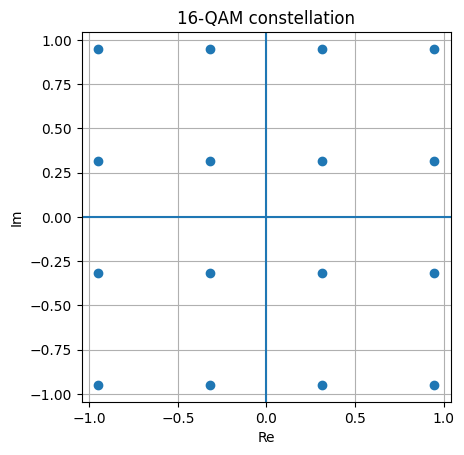

In [ ]:
# Example test:
M = 16
P = 1

cnt = constellation(M, P)

Es = np.mean(np.abs(cnt)**2)
print("Average energy =", Es)

plt.figure()
plt.scatter(cnt.real, cnt.imag)
plt.axhline(0)
plt.axvline(0)
plt.grid(True)
plt.gca().set_aspect('equal')
plt.xlabel("Re")
plt.ylabel("Im")
plt.title(f"{M}-QAM constellation")
plt.show()

---

##### Question 3

In [4]:
def gray_code(n):
    if n == 1:
        return ["0", "1"]

    g = ["0", "1"]
    for _ in range(1, n):
        g = ["0" + x for x in g] + ["1" + x for x in g[::-1]]
    return g

def gray_map_qam(M):
    m = int(np.sqrt(M))
    k = int(np.log2(m))   # bits per axis

    g = gray_code(k)

    labels = []
    for j in range(m):
        for i in range(m):
            labels.append(g[i] + g[j])

    return np.array(labels)

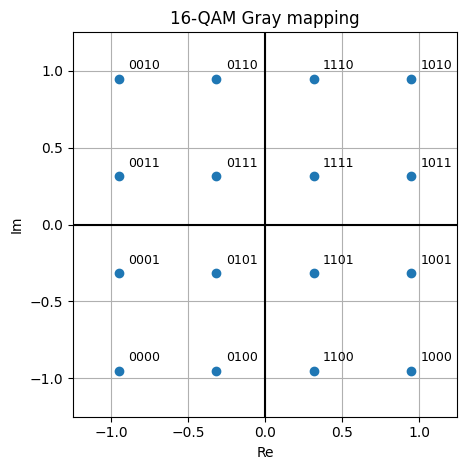

In [ ]:
#Example test:
M = 16
P = 1

cnt = constellation(M, P)
gray = gray_map_qam(M)


plt.figure()
plt.scatter(cnt.real, cnt.imag)

for i in range(M):
    plt.text(cnt[i].real + 0.06, cnt[i].imag + 0.06, gray[i], fontsize=9)

plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.grid(True)
plt.gca().set_aspect('equal')

plt.xlim(min(cnt.real) - 0.3, max(cnt.real) + 0.3)
plt.ylim(min(cnt.imag) - 0.3, max(cnt.imag) + 0.3)

plt.xlabel("Re")
plt.ylabel("Im")
plt.title(f"{M}-QAM Gray mapping")
plt.tight_layout()
plt.show()

---

##### Question 4

In [5]:
def bit_to_symb(b, cnt):
    M = len(cnt)
    k = int(np.log2(M))
    gray = gray_map_qam(M)

    table = dict(zip(gray, cnt))

    s = []
    for i in range(0, len(b), k):
        bits = ''.join(str(x) for x in b[i:i+k])
        s.append(table[bits])

    return np.array(s)

In [ ]:
# Example test:
M = 16
P = 1

cnt = constellation(M, P)
b = source(20, 0.5)
s = bit_to_symb(b, cnt)

print("bits =", b)
print("symbols =", s)

bits = [1 1 0 0 1 0 0 0 1 1 1 0 0 0 0 1 0 0 1 1]
symbols = [ 0.31622777-0.9486833j   0.9486833 -0.9486833j   0.31622777+0.9486833j
 -0.9486833 -0.31622777j -0.9486833 +0.31622777j]


---

#### 2.1.4 Symbols-to-signal mapping

##### Question 5

Each symbol in an $M$-QAM constellation carries $\log_2(M)$ bits.

If the symbol rate is $R_s$ symbols/s, then the bit rate is $R_b = R_s \log_2(M).$

For $M=16$, $\log_2(16)=4$, so $R_b = 4R_s.$

Now, the time interval between two consecutive sinc pulses is $T_s=\frac{1}{B}.$ Therefore, the symbol rate is $R_s=\frac{1}{T_s}=B.$

Hence the bit rate can also be written as $R_b = B\log_2(M).$

For $16$-QAM, $R_b = 4B.$

---

##### Question 6

Let $T_s = \frac{1}{B}$ be the symbol period, and let $\alpha \in [0,1]$ be the roll-off factor.

The root-raised-cosine (RRC) pulse has frequency response

$P_{\mathrm{RRC}}(f)=\begin{cases}\sqrt{T_s}, & |f|\le \dfrac{1-\alpha}{2T_s},\\[6pt]\sqrt{\dfrac{T_s}{2}\left[1+\cos\!\left(\dfrac{\pi T_s}{\alpha}\left(|f|-\dfrac{1-\alpha}{2T_s}\right)\right)\right]}, &\dfrac{1-\alpha}{2T_s}<|f|\le\dfrac{1+\alpha}{2T_s},\\[10pt]0, & |f|>\dfrac{1+\alpha}{2T_s}.\end{cases}$

Its time-domain expression is

$p_{\mathrm{RRC}}(t)=\frac{1}{\sqrt{T_s}}\frac{\sin\!\big(\pi(1-\alpha)t/T_s\big)+4\alpha (t/T_s)\cos\!\big(\pi(1+\alpha)t/T_s\big)}{\pi (t/T_s)\left(1-(4\alpha t/T_s)^2\right)},$

for the regular points $t\neq 0$ and $t\neq \pm \dfrac{T_s}{4\alpha}$.

At the singular points, the limiting values are

$p_{\mathrm{RRC}}(0)=\frac{1}{\sqrt{T_s}}\left(1+\alpha\left(\frac{4}{\pi}-1\right)\right),$ and $p_{\mathrm{RRC}}\!\left(\pm \frac{T_s}{4\alpha}\right)=\frac{\alpha}{\sqrt{2T_s}}\left[\left(1+\frac{2}{\pi}\right)\sin\!\left(\frac{\pi}{4\alpha}\right)+\left(1-\frac{2}{\pi}\right)\cos\!\left(\frac{\pi}{4\alpha}\right)\right].$

In practice, the transmitter uses the RRC pulse and the receiver uses the matched RRC filter. The convolution of the two gives a raised-cosine response, which satisfies the Nyquist zero-ISI condition at symbol sampling instants.

In [6]:
def rrc_pulse(t, B, alpha=0.25):

    Ts = 1.0 / B
    x  = t / Ts
    p  = np.zeros_like(t, dtype=float)

    for i, xi in enumerate(x):
        denom = np.pi * xi * (1.0 - (4.0 * alpha * xi)**2)
        if abs(xi) < 1e-10:                              # singular: t = 0
            p[i] = (1.0 + alpha * (4.0 / np.pi - 1.0)) / np.sqrt(Ts)
        elif abs(abs(4.0 * alpha * xi) - 1.0) < 1e-10:  # singular: t = ±Ts/4α
            A   = (1.0 + 2.0 / np.pi) * np.sin(np.pi / (4.0 * alpha))
            Bv  = (1.0 - 2.0 / np.pi) * np.cos(np.pi / (4.0 * alpha))
            p[i] = alpha / np.sqrt(2.0 * Ts) * (A + Bv)
        else:
            num  = (np.sin(np.pi * (1.0 - alpha) * xi)
                    + 4.0 * alpha * xi * np.cos(np.pi * (1.0 + alpha) * xi))
            p[i] = num / (denom * np.sqrt(Ts))
    return p

def _pulse_basis(t, B, ell, pulse='sinc', alpha=0.25):

    if pulse == 'sinc':
        return np.sinc(B * t - ell)
    elif pulse == 'rrc':
        return rrc_pulse(t - ell / B, B, alpha)
    else:
        raise ValueError(f"Unknown pulse: {pulse!r}")

Following the guide, we first validated the implementation using the sinc pulse shape. Once the transmitter and receiver chain were verified, we have also added the root-raised-cosine (RRC) pulse shape for the following experiments.

---

##### Question 7

In [7]:
def mod(t, s, B, pulse='sinc', alpha=0.25):
    Ns  = len(s)
    l1  = -(Ns // 2)
    l2  = int(np.ceil(Ns / 2)) - 1
    q0t = np.zeros(len(t), dtype=complex)
    for ell in range(l1, l2 + 1):
        phi  = _pulse_basis(t, B, ell, pulse, alpha)
        q0t += s[ell - l1] * phi
    return q0t


bits: [0 0 1 1 0 1 0 0 0 0 1 0]
symbols: [-0.9486833 +0.31622777j -0.31622777-0.9486833j  -0.9486833 +0.9486833j ]


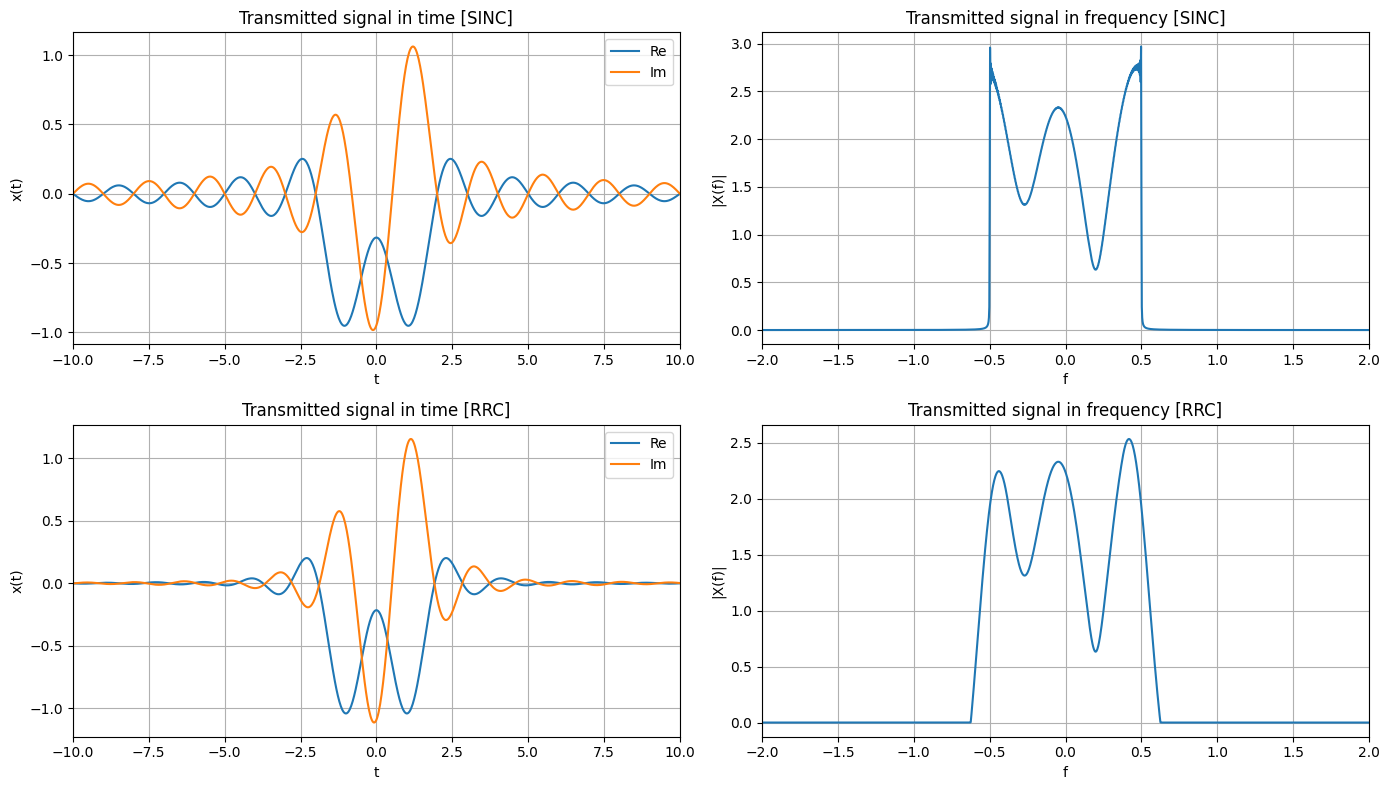

Energy of basis pulse [SINC] = 0.99949339
Energy of basis pulse [RRC] = 1.00000000


In [ ]:
T  = 400
N  = 2**14
dt = T / N
t  = np.arange(-N//2, N//2) * dt

df = 1 / T
f  = np.arange(-N//2, N//2) * df

M = 16
P = 1
B = 1
ns = 3
nb = ns * int(np.log2(M))
p  = 0.5

cnt = constellation(M, P)
b   = source(nb, p)
s   = bit_to_symb(b, cnt)

print("bits:", b)
print("symbols:", s)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, pulse in enumerate(["sinc", "rrc"]):
    q0t = mod(t, s, B, pulse=pulse, alpha=0.25)
    q0f = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(q0t))) * dt

    axes[row, 0].plot(t, q0t.real, label="Re")
    axes[row, 0].plot(t, q0t.imag, label="Im")
    axes[row, 0].set_xlim([-10, 10])
    axes[row, 0].set_xlabel("t")
    axes[row, 0].set_ylabel("x(t)")
    axes[row, 0].set_title(f"Transmitted signal in time [{pulse.upper()}]")
    axes[row, 0].grid(True)
    axes[row, 0].legend()

    axes[row, 1].plot(f, np.abs(q0f))
    axes[row, 1].set_xlim([-2, 2])
    axes[row, 1].set_xlabel("f")
    axes[row, 1].set_ylabel("|X(f)|")
    axes[row, 1].set_title(f"Transmitted signal in frequency [{pulse.upper()}]")
    axes[row, 1].grid(True)

plt.tight_layout()
plt.show()

for pulse in ["sinc", "rrc"]:
    phi = _pulse_basis(t, B, 0, pulse=pulse, alpha=0.25)
    E = np.sum(np.abs(phi)**2) * dt
    print(f"Energy of basis pulse [{pulse.upper()}] = {E:.8f}")

---

### 2.2 Channel Model
#### 2.2.2 Fiber-Optic Channel

##### Question 8

Using the the stochastic NLS :

$j \frac{\partial Q(\tau,\ell)}{\partial \ell}=-\frac{\beta_2}{2}\frac{\partial^2 Q(\tau,\ell)}{\partial \tau^2}+\gamma |Q(\tau,\ell)|^2 Q(\tau,\ell)+N(\tau,\ell).$

The left-hand side has unit $\left[\frac{\partial Q}{\partial \ell}\right]=\frac{\sqrt{\mathrm W}}{\mathrm m}.$

For the dispersion term, $\left[\frac{\partial^2 Q}{\partial \tau^2}\right]=\frac{\sqrt{\mathrm W}}{\mathrm s^2},$

so in order for $\beta_2 \frac{\partial^2 Q}{\partial \tau^2}$ to have unit $\sqrt{\mathrm W}/\mathrm m$, we must have $[\beta_2]=\frac{\mathrm s^2}{\mathrm m}.$

For the nonlinear term, $[|Q|^2Q]=(\sqrt{\mathrm W})^3,$ hence $[\gamma]=\frac{1}{\mathrm W \cdot \mathrm m}=\mathrm W^{-1}\mathrm m^{-1}.$

For the noise term, the guide gives the correlation $\mathbb E\!\left[N(\tau,\ell)N^*(\tau',\ell')\right]=\sigma_0^2 \, \delta_B(\tau-\tau') \, \delta(\ell-\ell').$ Since $\delta_B(\tau-\tau')$ has unit $1/\mathrm s$ and $\delta(\ell-\ell')$ has unit $1/\mathrm m$, and since the noise power formula is $P_n = \sigma_0^2 B L,$ it follows that $[\sigma_0^2]=\frac{\mathrm W}{\mathrm{Hz}\cdot \mathrm m}.$

Therefore,

$[\beta_2] = \mathrm s^2/\mathrm m,$

$[\gamma] = \mathrm W^{-1}\mathrm m^{-1},$

$[\sigma_0^2] = \mathrm W/(\mathrm{Hz}\cdot \mathrm m).$

---

##### Question 9

$q(t,z)=\frac{Q(\tau,\ell)}{\sqrt{P_0}}, \qquad t=\frac{\tau}{T_0}, \qquad z=\frac{\ell}{L}.$

Equivalently,

$Q(\tau,\ell)=\sqrt{P_0}\,q(t,z), \qquad \tau=T_0 t, \qquad \ell=L z.$

Using the chain rule,

$\frac{\partial Q}{\partial \ell} =\frac{\sqrt{P_0}}{L}\frac{\partial q}{\partial z},$

and

$\frac{\partial^2 Q}{\partial \tau^2}=\frac{\sqrt{P_0}}{T_0^2}\frac{\partial^2 q}{\partial t^2}.$

Also,

$|Q|^2Q=P_0^{3/2}|q|^2q.$

Substituting these expressions into the physical NLS equation gives

$j \frac{\sqrt{P_0}}{L}\frac{\partial q}{\partial z}=-\frac{\beta_2}{2}\frac{\sqrt{P_0}}{T_0^2}\frac{\partial^2 q}{\partial t^2}+\gamma P_0^{3/2}|q|^2q+N.$

Dividing by $\sqrt{P_0}/L$, we obtain

$j \frac{\partial q}{\partial z}=-\frac{\beta_2 L}{2T_0^2}\frac{\partial^2 q}{\partial t^2}+\gamma L P_0 |q|^2q+n(t,z),$

where $n(t,z)$ is the normalized noise term.

Now choose

$P_0=\frac{2}{\gamma \mathcal{L}}, \qquad T_0=\sqrt{\frac{|\beta_2|\mathcal{L}}{2}}, \qquad L=\mathcal{L}.$

Since $\beta_2<0$,

$-\frac{\beta_2 L}{2T_0^2}=1,$

and also

$\gamma L P_0 = 2.$

Therefore the normalized equation becomes

$j\frac{\partial q(t,z)}{\partial z}=\frac{\partial^2 q(t,z)}{\partial t^2}+2|q(t,z)|^2 q(t,z)+n(t,z).$

The normalized noise correlation is written as

$\mathbb E\!\left[n(t,z)n^*(t',z')\right]=\sigma^2 \, \delta_{B_n}(t-t') \, \delta(z-z'),$

with

$B_n = B T_0,$

and

$\sigma^2 = \frac{\sigma_0^2 \mathcal{L}}{P_0 T_0}.$

So the normalization removes the explicit physical parameters $\beta_2$ and $\gamma$, and the model is rewritten in dimensionless form.

---

##### Question 10

The fiber length is

$\mathcal{L} = 1000~\mathrm{km} = 10^6~\mathrm m.$

The loss coefficient is given by $a_{\mathrm{dB}}=0.2~\mathrm{dB/km}$. The guide gives

$\alpha = 10^{-4}\log(10)\,a_{\mathrm{dB}},$

hence

$\alpha = 10^{-4}\log(10)\times 0.2= 4.60517\times 10^{-5}~\mathrm m^{-1}.$

The dispersion parameter is

$D = 17~\mathrm{ps}/(\mathrm{nm}\cdot \mathrm{km}).$

Converting to SI units,

$D=17\times 10^{-12}\big/(10^{-9}\times 10^3)=17\times 10^{-6}~\mathrm s/\mathrm m^2.$

The carrier wavelength is

$\lambda_0 = 1.55~\mu\mathrm m = 1.55\times 10^{-6}~\mathrm m.$

The carrier frequency is

$f_0 = \frac{c}{\lambda_0}=\frac{3\times 10^8}{1.55\times 10^{-6}}=1.93548\times 10^{14}~\mathrm{Hz}.$

The nonlinearity coefficient is

$\gamma = 1.27~\mathrm W^{-1}\mathrm{km}^{-1}=1.27\times 10^{-3}~\mathrm W^{-1}\mathrm m^{-1}.$

The dispersion coefficient is obtained from

$\beta_2 = -\frac{\lambda_0^2}{2\pi c}D.$

Substituting the values,

$\beta_2=-\frac{(1.55\times 10^{-6})^2}{2\pi(3\times 10^8)}(17\times 10^{-6})=-2.16676\times 10^{-26}~\mathrm s^2/\mathrm m.$

The scale factors are

$L_0 = \mathcal{L} = 10^6~\mathrm m,$

$T_0=\sqrt{\frac{|\beta_2|\mathcal{L}}{2}}=\sqrt{\frac{(2.16676\times 10^{-26})(10^6)}{2}}=1.04086\times 10^{-10}~\mathrm s,$

and

$P_0=\frac{2}{\gamma \mathcal{L}}=\frac{2}{(1.27\times 10^{-3})(10^6)}=1.57480\times 10^{-3}~\mathrm W.$

The physical noise PSD is

$\sigma_0^2 = n_{sp} h \alpha f_0.$

With $n_{sp}=1$ and $h=6.626\times 10^{-34}~\mathrm{J\cdot s}$,

$\sigma_0^2=(1)(6.626 \times 10^{-34})(4.60517 \times 10^{-5})(1.93548 \times 10^{14})=5.90591 \times 10^{-24}~\mathrm{W}/(\mathrm{Hz}\cdot\mathrm{m}).$

The normalized noise variance is

$\sigma^2=\frac{\sigma_0^2 \mathcal{L}}{P_0 T_0}=\frac{(5.90591\times 10^{-24})(10^6)}{(1.57480\times 10^{-3})(1.04086\times 10^{-10})}=3.60305\times 10^{-5}.$

Finally, the normalized bandwidth is

$B_n = B T_0.$

In [8]:
# variables
L = 1000e3          # distance [m] = 1000 km
B = 10e9            # bandwidth [Hz], choose in [1e9, 10e9]

# physical constants
a_dB = 0.2          # power loss [dB/km]
D = 17e-12 / (1e-9 * 1e3)   # dispersion [s/m^2], converted from ps/(nm·km)
gama = 1.27e-3      # nonlinearity coefficient [W^-1 m^-1], converted from W^-1 km^-1
nsp = 1             # spontaneous emission factor
h = 6.626e-34       # Planck constant [J·s]
lambda0 = 1.55e-6   # center wavelength [m]
c = 3e8             # speed of light [m/s]

# physical quantities
f0 = c / lambda0
alpha = 1e-4 * np.log(10) * a_dB
beta2 = -(lambda0**2 / (2 * np.pi * c)) * D

# scale factors
L0 = L
T0 = np.sqrt(np.abs(beta2) * L / 2)
P0 = 2 / (gama * L)

# noise PSD
sigma02 = nsp * h * alpha * f0          # physical
sigma2 = sigma02 * L / (P0 * T0)        # normalized

# normalized bandwidth
Bn = B * T0

print("L       =", L)
print("B       =", B)
print("f0      =", f0)
print("alpha   =", alpha)
print("beta2   =", beta2)
print("L0      =", L0)
print("T0      =", T0)
print("P0      =", P0)
print("sigma02 =", sigma02)
print("sigma2  =", sigma2)
print("Bn      =", Bn)


L       = 1000000.0
B       = 10000000000.0
f0      = 193548387096774.2
alpha   = 4.605170185988092e-05
beta2   = -2.1667619210769113e-26
L0      = 1000000.0
T0      = 1.0408558788508886e-10
P0      = 0.0015748031496062992
sigma02 = 5.905907932714276e-24
sigma2  = 3.603045929292216e-05
Bn      = 1.0408558788508886


---

#### 2.2.3 Fiber-optic Channel in the Absence of the Nonlinearity

##### Question 11

Normalized NLS equation in the absence of nonlinearity:

$j \frac{\partial q(t,z)}{\partial z} = \frac{\partial^2 q(t,z)}{\partial t^2} + n(t,z).$

The guide defines the Fourier transform with respect to $t$ by

$\hat q(\omega,z) = \int_{-\infty}^{\infty} q(t,z)e^{-j\omega t}\,dt.$

Using the Fourier transform property

$\mathcal{F}\!\left\{\frac{\partial^2 q}{\partial t^2}\right\} = -\omega^2 \hat q(\omega,z),$

we obtain

$j \frac{\partial \hat q(\omega,z)}{\partial z}=-\omega^2 \hat q(\omega,z) + \hat n(\omega,z).$

Rewriting,

$\frac{\partial \hat q(\omega,z)}{\partial z} - j\omega^2 \hat q(\omega,z) = -j\hat n(\omega,z).$

This is a first-order linear differential equation in $z$.  
Multiplying by the integrating factor $e^{-j\omega^2 z}$ gives

$\frac{\partial}{\partial z}\Big(e^{-j\omega^2 z}\hat q(\omega,z)\Big)=-j e^{-j\omega^2 z}\hat n(\omega,z).$

Integrating from $0$ to $z$ yields

$e^{-j\omega^2 z}\hat q(\omega,z) - \hat q(\omega,0)=-j\int_0^z e^{-j\omega^2 \zeta}\hat n(\omega,\zeta)\,d\zeta.$

Multiplying both sides by $e^{j\omega^2 z}$, we obtain

$\hat q(\omega,z)=e^{j\omega^2 z}\hat q(\omega,0)-j\int_0^z e^{j\omega^2(z-\zeta)}\hat n(\omega,\zeta)\,d\zeta.$

Therefore the channel can be written in the required form

$\hat q(\omega,z)=\hat h(\omega,z)\hat q(\omega,0)+\hat z(\omega),$

where

$\hat h(\omega,z)=e^{j\omega^2 z}$

and, for a fixed propagation distance $z$,

$\hat z(\omega)=-j\int_0^z e^{j\omega^2(z-\zeta)}\hat n(\omega,\zeta)\,d\zeta.$

So the problem is to characterize the stochastic process $\hat z(\omega)$.


##### Mean of $\hat z(\omega)$

Since $n(t,z)$ is zero-mean circularly symmetric complex Gaussian noise, its Fourier transform $\hat n(\omega,z)$ is also zero mean. Therefore,

$E[\hat z(\omega)]=-j\int_0^z e^{j\omega^2(z-\zeta)} E[\hat n(\omega,\zeta)]\,d\zeta=0.$

Hence,

$E[\hat z(\omega)] = 0.$


##### Correlation of $\hat n(\omega,z)$

From the guide, the normalized noise satisfies

$E[n(t,z)n^*(t',z')]=\sigma^2 \delta_{B_n}(t-t')\delta(z-z'),$

where $B_n = BT_0$.

We now take the Fourier transform with respect to $t$:

$E[\hat n(\omega,z)\hat n^*(\omega',z')]=\int\!\!\int E[n(t,z)n^*(t',z')]e^{-j\omega t}e^{j\omega' t'}\,dt\,dt'.$

Substituting the autocorrelation,

$E[\hat n(\omega,z)\hat n^*(\omega',z')]=\sigma^2 \delta(z-z')\int\!\!\int\delta_{B_n}(t-t') e^{-j\omega t}e^{j\omega' t'}\,dt\,dt'.$

The Fourier transform of $\delta_{B_n}(t-t')$ is the indicator of the band $|\omega|\le \pi B_n$. Therefore,

$E[\hat n(\omega,z)\hat n^*(\omega',z')]=2\pi \sigma^2 \mathbf{1}_{\{|\omega|\le \pi B_n\}}\delta(\omega-\omega')\delta(z-z').$

Thus the frequency-domain noise is white in $\omega$ inside the band.


##### Correlation of $\hat z(\omega)$

Using the expression of $\hat z(\omega)$,

$\hat z(\omega)=-j\int_0^z e^{j\omega^2(z-\zeta)}\hat n(\omega,\zeta)\,d\zeta,$

we compute

$E[\hat z(\omega)\hat z^*(\omega')]=\int_0^z\int_0^ze^{j\omega^2(z-\zeta)}e^{-j{\omega'}^2(z-\zeta')}E[\hat n(\omega,\zeta)\hat n^*(\omega',\zeta')]\,d\zeta\,d\zeta'.$

Substituting the correlation of $\hat n$,

$E[\hat z(\omega)\hat z^*(\omega')]=2\pi \sigma^2 \mathbf{1}_{\{|\omega|\le \pi B_n\}} \delta(\omega-\omega')\int_0^z\int_0^z e^{j\omega^2(z-\zeta)} e^{-j{\omega'}^2(z-\zeta')}\delta(\zeta-\zeta') \,d\zeta\,d\zeta'.$

The Dirac delta $\delta(\zeta-\zeta')$ collapses one integral, so

$E[\hat z(\omega)\hat z^*(\omega')]=2\pi \sigma^2 \mathbf{1}_{\{|\omega|\le \pi B_n\}} \delta(\omega-\omega')\int_0^ze^{j\omega^2(z-\zeta)}e^{-j{\omega'}^2(z-\zeta)}\,d\zeta.$

Because of the factor $\delta(\omega-\omega')$, we can set $\omega'=\omega$ inside the integral. The exponential terms cancel, giving

$E[\hat z(\omega)\hat z^*(\omega')]=2\pi \sigma^2 z \,\mathbf{1}_{\{|\omega|\le \pi B_n\}} \delta(\omega-\omega').$

Therefore, the correlation function of $\hat z(\omega)$ is

$E[\hat z(\omega)\hat z^*(\omega')]=2\pi \sigma^2 z \,\mathbf{1}_{\{|\omega|\le \pi B_n\}} \delta(\omega-\omega').$

This shows that $\hat z(\omega)$ is a white circularly symmetric complex Gaussian process in frequency over the noise band, and its variance grows linearly with the propagation distance $z$.

##### PDF of $\hat z(\omega)$

Since $\hat z(\omega)$ is a linear transform of the Gaussian noise $n(t,z)$, it is also a circularly symmetric complex Gaussian process.

In continuous frequency, the most precise characterization is therefore through its mean and correlation function rather than a pointwise scalar PDF.

For a fixed propagation distance $z$, $\hat z(\omega)$ is a zero-mean circularly symmetric complex Gaussian process satisfying

$E[\hat z(\omega)] = 0,$ and $E[\hat z(\omega)\hat z^*(\omega')]=2\pi \sigma^2 z\,\mathbf{1}_{\{|\omega|\le \pi B_n\}}\,\delta(\omega-\omega').$

Thus, $\hat z(\omega)$ is white in frequency over the band $|\omega|\le \pi B_n$, and its power grows linearly with the propagation distance $z$.

After discretization on the frequency mesh, the in-band frequency samples become complex Gaussian random variables.

##### Final answer

For a fixed propagation distance $z$, the linearized channel in frequency is

$\hat q(\omega,z)=e^{j\omega^2 z}\hat q(\omega,0)+\hat z(\omega),$ where $\hat z(\omega)$ is a zero-mean circularly symmetric complex Gaussian process.

Its mean is $E[\hat z(\omega)] = 0,$ and its autocorrelation function is $E[\hat z(\omega)\hat z^*(\omega')]= 2\pi \sigma^2 z\,\mathbf{1}_{\{|\omega|\le \pi B_n\}}\,\delta(\omega-\omega').$

Therefore, $\hat z(\omega)$ is white in frequency over the band $|\omega|\le \pi B_n$, and its power grows linearly with the propagation distance $z$.

After discretization on the frequency mesh, the in-band frequency samples become circularly symmetric complex Gaussian random variables.

---

##### Question 12

Linearized channel in the frequency domain is

$\hat q(\omega,z)=\hat h(\omega,z)\hat q(\omega,0)+\hat z(\omega),$

with

$\hat h(\omega,z)=e^{j\omega^2 z}.$

Taking the inverse Fourier transform, we obtain the time-domain channel

$q(t,z)=h(t,z)\star q(t,0)+z(t),$

where

$h(t,z)=\mathcal{F}^{-1}\{\hat h(\omega,z)\}(t)$

and

$z(t)=\mathcal{F}^{-1}\{\hat z(\omega)\}(t).$


##### Channel impulse response $h(t,z)$

Using the inverse Fourier transform convention,

$h(t,z)=\frac{1}{2\pi}\int_{-\infty}^{\infty} e^{j\omega^2 z}e^{j\omega t}\,d\omega.$

We complete the square in the exponent:

$z\omega^2+t\omega=z\left(\omega+\frac{t}{2z}\right)^2-\frac{t^2}{4z}.$

Hence

$h(t,z)=\frac{e^{-j t^2/(4z)}}{2\pi}\int_{-\infty}^{\infty}e^{jz\left(\omega+\frac{t}{2z}\right)^2}d\omega.$

With the change of variable

$u=\omega+\frac{t}{2z},$

this becomes

$h(t,z)=\frac{e^{-j t^2/(4z)}}{2\pi}\int_{-\infty}^{\infty} e^{jzu^2}\,du.$

We know

$\int_{-\infty}^{\infty} e^{jzu^2}\,du=\sqrt{\frac{\pi}{z}}\,e^{j\pi/4},\qquad z>0,$

we get

$h(t,z)=\frac{e^{j\pi/4}}{\sqrt{4\pi z}}\exp\!\left(-j\frac{t^2}{4z}\right),\qquad z>0.$

Therefore, the channel impulse response is

$h(t,z)=\frac{e^{j\pi/4}}{\sqrt{4\pi z}}\exp\!\left(-j\frac{t^2}{4z}\right).$


##### PDF of $z(t)$

From Question 10, $\hat z(\omega)$ is a zero-mean circularly symmetric complex Gaussian process. Since $z(t)$ is obtained from $\hat z(\omega)$ by an inverse Fourier transform, which is linear, $z(t)$ is also a zero-mean circularly symmetric complex Gaussian process.

Therefore, the PDF of $z(t)$ is Gaussian in the complex sense. More precisely, for each fixed time $t$,

$z(t)\sim \mathcal{CN}(0,\sigma^2 z B_n).$

So $z(t)$ is a bandlimited white circularly symmetric complex Gaussian noise process in time.


##### Mean of $z(t)$

Since $\hat z(\omega)$ has zero mean, its inverse Fourier transform also has zero mean:

$E[z(t)]=\mathcal{F}^{-1}\{E[\hat z(\omega)]\}(t)=0.$

Hence,

$E[z(t)] = 0.$


##### Correlation of $z(t)$

From Question 10, the correlation of $\hat z(\omega)$ is

$E[\hat z(\omega)\hat z^*(\omega')]=2\pi \sigma^2 z \,\mathbf{1}_{\{|\omega|\le \pi B_n\}}\delta(\omega-\omega').$

Now compute the time-domain correlation:

$E[z(t)z^*(t')]=\frac{1}{(2\pi)^2}\int_{-\infty}^{\infty}\int_{-\infty}^{\infty}E[\hat z(\omega)\hat z^*(\omega')]e^{j\omega t}e^{-j\omega' t'}\,d\omega\,d\omega'.$

Substituting the expression above,

$E[z(t)z^*(t')]=\frac{1}{(2\pi)^2}\int\!\!\int2\pi \sigma^2 z \,\mathbf{1}_{\{|\omega|\le \pi B_n\}}\delta(\omega-\omega')e^{j\omega t}e^{-j\omega' t'}\,d\omega\,d\omega'.$

Using the Dirac delta $\delta(\omega-\omega')$, we obtain

$E[z(t)z^*(t')]=\frac{\sigma^2 z}{2\pi}\int_{-\pi B_n}^{\pi B_n}e^{j\omega(t-t')}\,d\omega.$

Evaluating the integral,

$E[z(t)z^*(t')]=\sigma^2 z\, B_n\,\mathrm{sinc}\!\big(B_n(t-t')\big).$

Since the guide defines

$\delta_{B_n}(x)=B_n\,\mathrm{sinc}(B_n x),$

we can write the result as

$E[z(t)z^*(t')]=\sigma^2 z\,\delta_{B_n}(t-t').$

Therefore, $z(t)$ is a zero-mean bandlimited white circularly symmetric complex Gaussian process with autocorrelation

$E[z(t)z^*(t')]=\sigma^2 z\,\delta_{B_n}(t-t').$


##### Final answer

The time-domain channel is

$q(t,z)=h(t,z)\star q(t,0)+z(t),$

with impulse response

$h(t,z)=\frac{e^{j\pi/4}}{\sqrt{4\pi z}}\exp\!\left(-j\frac{t^2}{4z}\right).$

The additive term $z(t)$ is a zero-mean circularly symmetric complex Gaussian process. Its statistics are

$E[z(t)] = 0,$

and

$E[z(t)z^*(t')]=\sigma^2 z\,\delta_{B_n}(t-t').$

Equivalently, for each fixed $t$,

$z(t)\sim \mathcal{CN}(0,\sigma^2 z B_n).$

---

#### 2.2.4 Continuous- and Discrete-time Models

##### Question 13

The continuous-time input-power constraint is

$P = \lim_{T\to\infty}\frac{1}{T}\,E\!\left[\int_{-T/2}^{T/2}|q(t,0)|^2\,dt\right].$

To discretize it, we sample the interval $[-T/2,T/2)$ uniformly with $N$ points and step

$\Delta t = \frac{T}{N}.$

Let

$t_i = -\frac{T}{2} + i\Delta t, \qquad i=0,1,\dots,N-1,$

and define the samples

$q_i(0) = q(t_i,0).$

Approximating the integral by a Riemann sum gives

$\int_{-T/2}^{T/2}|q(t,0)|^2\,dt \approx\sum_{i=0}^{N-1}|q_i(0)|^2\,\Delta t.$

Substituting this into the power expression,

$P \approx \frac{1}{T}E\!\left[\sum_{i=0}^{N-1}|q_i(0)|^2\,\Delta t\right].$

Since $\Delta t = T/N$, we get

$P\approx \frac{1}{T}\cdot \frac{T}{N}\sum_{i=0}^{N-1}E|q_i(0)|^2=\frac{1}{N}\sum_{i=0}^{N-1}E|q_i(0)|^2.$

Therefore, in the limit $N\to\infty$,

$P=\lim_{N\to\infty}\frac{1}{N}\sum_{i=0}^{N-1}E|q_i(0)|^2.$

So the discrete-time version of the input-power constraint is

$\frac{1}{N}E\|\mathbf q(0)\|_2^2 \approx P,$

where

$\mathbf q(0)=\big(q_0(0),q_1(0),\dots,q_{N-1}(0)\big)^T.$

---

##### Question 14

Let $t_n = -\frac{T}{2} + n\Delta t, \qquad n=0,1,\dots,N-1,$ with $\Delta t = \frac{T}{N}.$

The corresponding frequency mesh is

$f_k = -\frac{F}{2} + k\Delta f, \qquad k=0,1,\dots,N-1,$ where $F=\frac{1}{\Delta t}, \qquad \Delta f = \frac{1}{T}.$

In angular frequency,

$\omega_k = 2\pi f_k, \qquad \Delta\omega = 2\pi\Delta f = \frac{2\pi}{T}.$


##### 1. Discretization of the Fourier integrals

The continuous Fourier transform is

$\hat x(\omega)=\int_{-\infty}^{\infty} x(t)e^{-j\omega t}\,dt.$

Sampling in time and approximating the integral by a Riemann sum gives

$\hat x(\omega_k)\approx\sum_{n=0}^{N-1} x(t_n)e^{-j\omega_k t_n}\,\Delta t.$

If we define

$x_n = x(t_n),$

then this becomes

$\hat x(\omega_k)\approx\Delta t \sum_{n=0}^{N-1} x_n e^{-j\omega_k t_n}.$

So we obtain

$\hat x(\omega_k)\approx\Delta t\,\hat x_k,$ where $\hat x_k = \sum_{n=0}^{N-1} x_n e^{-j2\pi nk/N}$ is the DFT of the sampled signal.

Now consider the inverse Fourier transform

$x(t)=\frac{1}{2\pi}\int_{-\infty}^{\infty}\hat x(\omega)e^{j\omega t}\,d\omega.$

Approximating the integral by a Riemann sum on the frequency mesh gives

$x(t_n)\approx\frac{1}{2\pi}\sum_{k=0}^{N-1}\hat x(\omega_k)e^{j\omega_k t_n}\,\Delta\omega.$

Since $\Delta\omega = 2\pi/T$,

$x_n\approx\frac{1}{T}\sum_{k=0}^{N-1}\hat x(\omega_k)e^{j2\pi nk/N}.$

Using $\hat x(\omega_k)\approx \Delta t\,\hat x_k$ and $T=N\Delta t$, we get

$x_n\approx\frac{1}{N}\sum_{k=0}^{N-1}\hat x_k e^{j2\pi nk/N}.$

Thus, the Fourier integrals reduce to the DFT/IDFT pair

$\hat x(\omega_k)\approx \Delta t\,\hat x_k,$  and  $x_n \approx \frac{1}{N}\sum_{k=0}^{N-1}\hat x_k e^{j2\pi nk/N}.$


##### 2. Approximation of the channel in the frequency domain

From Question 10, the linearized channel in frequency is

$\hat q(\omega,z)=\hat h(\omega,z)\hat q(\omega,0)+\hat z(\omega),$ with $\hat h(\omega,z)=e^{j\omega^2 z}.$

Sampling this expression at $\omega=\omega_k$ and using
$\hat q(\omega_k,z)\approx \Delta t\,\hat q_k(z)$, we obtain

$\Delta t\,\hat q_k(z)\approx e^{j\omega_k^2 z}\,\Delta t\,\hat q_k(0)+\hat z(\omega_k).$

Dividing by $\Delta t$,

$\hat q_k(z)\approx e^{j\omega_k^2 z}\hat q_k(0)+\hat z_k,$ where $\hat z_k = \frac{\hat z(\omega_k)}{\Delta t}.$

Therefore, in vector form, the discrete frequency-domain channel is

$\hat{\mathbf q}(z)=\Gamma(z)\hat{\mathbf q}(0)+\hat{\mathbf z},$ where $\Gamma(z)=\mathrm{diag}\!\big(e^{j\omega_0^2 z},e^{j\omega_1^2 z},\dots,e^{j\omega_{N-1}^2 z}\big).$


##### 3. Time-domain channel model

Applying the inverse DFT, the discrete time-domain channel becomes

$\mathbf q(z)=D^{-1}\Gamma(z)D\,\mathbf q(0)+\mathbf z,$ where $D$ is the DFT matrix.

Equivalently, $\mathbf q(z)=W(z)\mathbf q(0)+\mathbf z,$ with $W(z)=D^{-1}\Gamma(z)D.$

##### 4. Input constraints in time and frequency

From Question 12, the discrete-time input-power constraint is $\frac{1}{N}E\|\mathbf q(0)\|_2^2 \approx P.$

Using Parseval’s identity for the DFT convention used here,

$\sum_{n=0}^{N-1}|q_n(0)|^2=\frac{1}{N}\sum_{k=0}^{N-1}|\hat q_k(0)|^2.$

Therefore,

$\frac{1}{N}E\|\mathbf q(0)\|_2^2=\frac{1}{N^2}E\|\hat{\mathbf q}(0)\|_2^2.$

Hence the equivalent frequency-domain constraint is $\frac{1}{N^2}E\|\hat{\mathbf q}(0)\|_2^2 \approx P.$


##### Final summary

The sampled frequency-domain channel is $\hat{\mathbf q}(z)=\Gamma(z)\hat{\mathbf q}(0)+\hat{\mathbf z},$ with $\Gamma_{k,k}(z)=e^{j\omega_k^2 z}.$

The sampled time-domain channel is $\mathbf q(z)=W(z)\mathbf q(0)+\mathbf z,$ with $W(z)=D^{-1}\Gamma(z)D.$

The input-power constraint is $\frac{1}{N}E\|\mathbf q(0)\|_2^2 \approx P,$ or equivalently, $\frac{1}{N^2}E\|\hat{\mathbf q}(0)\|_2^2 \approx P.$

---


##### Question 15

To discretize the noise, we sample the time-domain additive noise process on the mesh $t_0,\dots,t_{N-1}$ and obtain a vector $\mathbf n(z)\in\mathbb C^N$.

From the continuous-time autocorrelation
$E[n(t,z)n^*(t',z')] = \sigma^2 \delta_B(t-t')\delta(z-z')$,
the sampled discrete autocorrelation at a fixed distance $z$ is

$E[n_i(z)n_j^*(z)]=\sigma^2 z\,\delta_B(t_i-t_j)=\sigma^2 z\,B\,\mathrm{sinc}(B(t_i-t_j)).$

Hence the discrete noise covariance matrix is

$E[\mathbf{n}(z)\mathbf{n}(z)^H]=\left[\sigma^2 z\,B\,\mathrm{sinc}\!\big(B(t_i-t_j)\big)\right]_{i,j}.$

The variance of each sample is obtained by setting $i=j$:

$E[|n_i(z)|^2]=\sigma^2 z\,B\,\mathrm{sinc}(0)=\sigma^2 B z.$

Rather than generating correlated Gaussian noise directly in time, we generate white Gaussian noise over the in-band frequency bins and then apply the inverse FFT. This produces a bandlimited Gaussian time-domain noise vector whose power matches the sampled continuous-time model.

In [9]:
def channel(t, q0t, z, sigma2, B):
    a = sigma2 * B * z

    N = len(t)
    dt = t[1] - t[0]
    T = N * dt
    df = 1 / T
    f = np.arange(-N//2, N//2) * df
    w = 2 * np.pi * f

    q0f = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(q0t))) * dt
    qzf = q0f * np.exp(1j * w**2 * z)

    nf = np.zeros(N, dtype=complex)
    mask = np.abs(f) <= B / 2
    K = np.count_nonzero(mask)

    if K > 0 and a > 0:
        var_f = a * T**2 / K
        nf[mask] = np.sqrt(var_f / 2) * (
            np.random.randn(K) + 1j * np.random.randn(K)
        )

    qzf = qzf + nf
    qzt = np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(qzf))) / dt

    return qzt, qzf


---

### 2.3 Receiver
#### 2.3.1 Linear Equalization
##### Question 16

From Question 10, before equalization the linear channel in frequency is

$\hat q(\omega,L)=\hat h(\omega,L)\hat q(\omega,0)+\hat z(\omega),$ with $\hat h(\omega,L)=e^{j\omega^2L}.$

The guide defines the equalized signal by

$\hat q_e(\omega,L)=\hat h^{-1}(\omega,L)\hat q(\omega,L)=\hat q(\omega,0)+\hat w(\omega),$ where $\hat w(\omega)=\hat h^{-1}(\omega,L)\hat z(\omega).$

In time domain, $q_e(t,L)=q(t,0)+w(t),$ where $w(t)=\mathcal F^{-1}\{\hat w(\omega)\}(t).$


##### 1. Characterization of $\hat w(\omega)$

Since $\hat z(\omega)$ is a zero-mean circularly symmetric complex Gaussian process and $\hat w(\omega)$ is obtained by multiplying it by the deterministic function $\hat h^{-1}(\omega,L)$, the process $\hat w(\omega)$ is also circularly symmetric complex Gaussian.

Its mean is

$E[\hat w(\omega)] =\hat h^{-1}(\omega,L)E[\hat z(\omega)]=0.$

Now compute the autocorrelation:

$E[\hat w(\omega)\hat w^*(\omega')]=\hat h^{-1}(\omega,L)\hat h^{-1}(\omega',L)^*E[\hat z(\omega)\hat z^*(\omega')].$

From Question 10,

$E[\hat z(\omega)\hat z^*(\omega')]=2\pi\sigma^2L\,\mathbf 1_{\{|\omega|\le \pi B_n\}}\delta(\omega-\omega').$

Also, $\hat h^{-1}(\omega,L)=e^{-j\omega^2L},$

so $\hat h^{-1}(\omega,L)\hat h^{-1}(\omega',L)^*=e^{-j\omega^2L}e^{j{\omega'}^2L}.$

Because of the factor $\delta(\omega-\omega')$, we set $\omega'=\omega$, and the phase terms cancel. Hence $E[\hat w(\omega)\hat w^*(\omega')]=2\pi\sigma^2L\,\mathbf 1_{\{|\omega|\le \pi B_n\}}\delta(\omega-\omega').$

Therefore, $\hat w(\omega)$ has exactly the same second-order statistics as $\hat z(\omega)$.

So the frequency-domain equalization does not amplify the noise power, because the channel is all-pass:

$|\hat h(\omega,L)|=1.$


##### 2. PDF of $\hat w(\omega)$

As a stochastic process, $\hat w(\omega)$ is a zero-mean circularly symmetric complex Gaussian process in frequency.

Strictly speaking, in continuous frequency it is best characterized by its mean and correlation function above.

After discretization on the frequency mesh, each in-band frequency sample is complex Gaussian with

$\hat w_k \sim \mathcal{CN}(0,\,2\pi\sigma^2L),$

for the bins satisfying $|\omega_k|\le \pi B_n$.

So the pointwise PDF of each in-band discrete coefficient is

$p_{\hat w_k}(u)=\frac{1}{\pi(2\pi\sigma^2L)}\exp\!\left(-\frac{|u|^2}{2\pi\sigma^2L}\right).$

Outside the noise band, the variance is zero.


##### 3. Characterization of $w(t)$

Since $w(t)=\mathcal F^{-1}\{\hat w(\omega)\}(t)$ and the inverse Fourier transform is linear, $w(t)$ is also a circularly symmetric complex Gaussian process.

Its mean is $E[w(t)]=\mathcal F^{-1}\{E[\hat w(\omega)]\}(t)=0.$

Its autocorrelation is the inverse Fourier transform of the frequency-domain autocorrelation. Therefore,

$E[w(t)w^*(t')]=\sigma^2L\,\delta_{B_n}(t-t'),$ where $\delta_{B_n}(x)=B_n\,\mathrm{sinc}(B_nx).$

Thus, $w(t)$ is a zero-mean bandlimited white circularly symmetric complex Gaussian process in time.

Its variance is obtained by setting $t=t'$:

$E[|w(t)|^2]=\sigma^2L\,\delta_{B_n}(0)=\sigma^2LB_n.$


##### 4. PDF of $w(t)$

For each fixed time $t$, the random variable $w(t)$ is circularly symmetric complex Gaussian with

$w(t)\sim \mathcal{CN}(0,\sigma^2LB_n).$

Hence its PDF is

$p_{w(t)}(u)=\frac{1}{\pi\sigma^2LB_n}\exp\!\left(-\frac{|u|^2}{\sigma^2LB_n}\right).$


##### Final answer

The equalized noise in frequency, $\hat w(\omega)=\hat h^{-1}(\omega,L)\hat z(\omega),$ is a zero-mean circularly symmetric complex Gaussian process with $E[\hat w(\omega)] = 0,$ and $E[\hat w(\omega)\hat w^*(\omega')]=2\pi\sigma^2L\,\mathbf 1_{\{|\omega|\le \pi B_n\}}\delta(\omega-\omega').$

So $\hat w(\omega)$ has the same statistics as $\hat z(\omega)$, because equalization multiplies by a unit-modulus phase factor only.

In time domain, the equalized noise $w(t)$ is also a zero-mean circularly symmetric complex Gaussian process with $E[w(t)] = 0,$ and $E[w(t)w^*(t')]=\sigma^2L\,\delta_{B_n}(t-t').$

For each fixed time $t$, $w(t)\sim \mathcal{CN}(0,\sigma^2LB_n).$

---

##### Question 17

In [10]:
def equalize(t, qzt, z):
    # get the f vector from t vector
    N = len(t)
    dt = t[1] - t[0]
    T = N * dt
    df = 1 / T
    f = np.arange(-N//2, N//2) * df
    w = 2 * np.pi * f

    # input in frequency
    qzf = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(qzt))) * dt

    # output in frequency
    qzfe = qzf * np.exp(-1j * w**2 * z)

    # back to time
    qzte = np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(qzfe))) / dt

    return qzte, qzfe

Test Script:

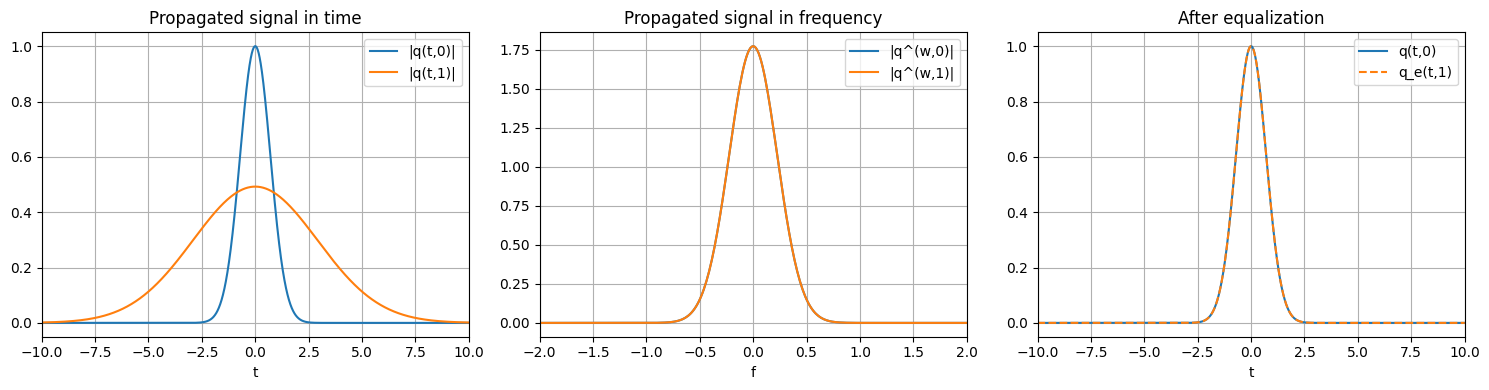

max |q(t,0) - q_e(t,1)| = 6.6620e-16


In [ ]:
T  = 80
N  = 2**14
dt = T / N
t  = np.arange(-N//2, N//2) * dt
df = 1 / T
f  = np.arange(-N//2, N//2) * df

z = 1.0

q0t = np.exp(-t**2)
q0f = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(q0t))) * dt

qzt, qzf   = channel(t, q0t, z, sigma2=0.0, B=1.0)
qzte, qzfe = equalize(t, qzt, z)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(t, np.abs(q0t), label='|q(t,0)|')
axes[0].plot(t, np.abs(qzt), label='|q(t,1)|')
axes[0].set_xlim([-10, 10])
axes[0].set_title("Propagated signal in time")
axes[0].set_xlabel("t")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(f, np.abs(q0f), label='|q^(w,0)|')
axes[1].plot(f, np.abs(qzf), label='|q^(w,1)|')
axes[1].set_xlim([-2, 2])
axes[1].set_title("Propagated signal in frequency")
axes[1].set_xlabel("f")
axes[1].grid(True)
axes[1].legend()

axes[2].plot(t, q0t.real, label='q(t,0)')
axes[2].plot(t, qzte.real, '--', label='q_e(t,1)')
axes[2].set_xlim([-10, 10])
axes[2].set_title("After equalization")
axes[2].set_xlabel("t")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

err = np.max(np.abs(q0t - qzte))
print(f"max |q(t,0) - q_e(t,1)| = {err:.4e}")



---

#### 2.3.2 Demodulation
##### Queation 18

In [11]:

def demod(t, qzte, B, Ns, pulse='sinc', alpha=0.25):
    dt   = t[1] - t[0]

    l1   = -(Ns // 2)
    l2   = int(np.ceil(Ns / 2)) - 1

    shat = np.zeros(Ns, dtype=complex)

    for i, ell in enumerate(range(l1, l2 + 1)):
        phi      = _pulse_basis(t, B, ell, pulse, alpha)
        shat[i]  = B * dt * np.vdot(phi, qzte)

    return shat

---

#### 2.3.3 Detection
##### Question 19

After equalization we have $q_e(t,z)=q(t,0)+w(t).$

From the modulation model $q(t,0)=\sum_k s_k \,\mathrm{sinc}(Bt-k).$

Substituting this into the demodulation formula

$\hat s_\ell = B\int_{-\infty}^{\infty} q_e(t,z)\,\mathrm{sinc}(Bt-\ell)\,dt,$

we obtain $\hat s_\ell=B\int_{-\infty}^{\infty}\left(\sum_k s_k\,\mathrm{sinc}(Bt-k)+w(t)\right)\mathrm{sinc}(Bt-\ell)\,dt.$

By linearity, $\hat s_\ell=\sum_k s_k\, B\int_{-\infty}^{\infty}\mathrm{sinc}(Bt-k)\,\mathrm{sinc}(Bt-\ell)\,dt+B\int_{-\infty}^{\infty} w(t)\,\mathrm{sinc}(Bt-\ell)\,dt.$

Now use the orthogonality of the sinc pulses:

$B\int_{-\infty}^{\infty}\mathrm{sinc}(Bt-k)\,\mathrm{sinc}(Bt-\ell)\,dt=\delta_{k\ell}.$

Therefore, $\hat s_\ell = s_\ell + Z_\ell,$ where $Z_\ell =B\int_{-\infty}^{\infty} w(t)\,\mathrm{sinc}(Bt-\ell)\,dt.$

So the continuous-time channel is reduced to the discrete-time channel

$s^{n_s} \longrightarrow \hat s^{n_s}, \qquad \hat s_\ell = s_\ell + Z_\ell.$


##### Distribution of $Z_\ell$

Since $w(t)$ is a zero-mean circularly symmetric complex Gaussian process, and $Z_\ell$ is a linear functional of $w(t)$, the random variable $Z_\ell$ is also circularly symmetric complex Gaussian.

Its mean is $E[Z_\ell]=B\int_{-\infty}^{\infty} E[w(t)]\,\mathrm{sinc}(Bt-\ell)\,dt=0.$

To compute the correlation, use the autocorrelation of the equalized noise from Question 16:

$E[w(t)w^*(t')]=\sigma^2 z\,\delta_B(t-t'),$ where $\delta_B(x)=B\,\mathrm{sinc}(Bx).$

Then $E[Z_\ell Z_m^*]=B^2\int_{-\infty}^{\infty}\int_{-\infty}^{\infty}E[w(t)w^*(t')]\mathrm{sinc}(Bt-\ell)\mathrm{sinc}(Bt'-m)\,dt\,dt'.$

Substituting the correlation of $w(t)$,$E[Z_\ell Z_m^*]=\sigma^2 z\, B^2\int\!\!\int\delta_B(t-t')\mathrm{sinc}(Bt-\ell)\mathrm{sinc}(Bt'-m)\,dt\,dt'.$

Since $\delta_B$ acts as the reproducing kernel for bandlimited signals, $\int_{-\infty}^{\infty}\delta_B(t-t')\,\mathrm{sinc}(Bt'-m)\,dt'=\mathrm{sinc}(Bt-m).$ Hence $E[Z_\ell Z_m^*]=\sigma^2 z\, B^2\int_{-\infty}^{\infty}\mathrm{sinc}(Bt-\ell)\mathrm{sinc}(Bt-m)\,dt.$

Using again the orthogonality relation, $\int_{-\infty}^{\infty} \mathrm{sinc}(Bt-\ell)\mathrm{sinc}(Bt-m)\,dt=\frac{1}{B}\delta_{\ell m},$

we obtain $E[Z_\ell Z_m^*]=\sigma^2 B z \,\delta_{\ell m}.$

Therefore, the variables $Z_\ell$ are uncorrelated. Since they are jointly Gaussian, they are in fact independent. They are also identically distributed, so $Z_\ell \overset{\mathrm{i.i.d.}}{\sim} \mathcal{CN}(0,c),$ with $c=\sigma^2 B z.$

At the receiver, the normalized propagation distance is $z=1$, so the final variance is $c=\sigma^2 B.$

In physical units, this corresponds to $c=\sigma_0^2 B L.$


##### Memoryless channel

Since $\hat s_\ell = s_\ell + Z_\ell,$ with $Z_\ell$ i.i.d. Gaussian, the conditional distribution factorizes:

$p(\hat s^{n_s}\mid s^{n_s})=\prod_{\ell=1}^{n_s} p(\hat s_\ell\mid s_\ell).$

Hence the discrete-time channel is memoryless.


##### Conditional PDF and ML detector

For each symbol, the conditional distribution is complex Gaussian:

$p(\hat s_\ell\mid s_\ell)=\frac{1}{\pi c}\exp\!\left(-\frac{|\hat s_\ell-s_\ell|^2}{c}\right).$

Therefore, the maximum-likelihood detector is $\tilde s_\ell=\arg\max_{a\in\mathcal C} p(\hat s_\ell\mid a).$

Since the exponential is monotone, maximizing the PDF is equivalent to minimizing the squared distance:

$\tilde s_\ell=\arg\min_{a\in\mathcal C} |\hat s_\ell-a|^2.$

So the ML detector for this AWGN discrete-time channel is simply the minimum-distance detector.


#### Decision regions

The decision region of a constellation point $a\in\mathcal C$ is

$\mathcal D(a)=\left\{u\in\mathbb C:\ |u-a|^2 \le |u-b|^2,\ \forall b\in\mathcal C\right\}.$

These are the Voronoi regions of the constellation points.  
For square QAM, the decision boundaries are the midpoints between neighboring constellation points, so detection is nearest-neighbor slicing in the complex plane.

In [12]:
def detector(shat, cnt):
    shat = np.asarray(shat).reshape(-1)
    cnt = np.asarray(cnt).reshape(-1)

    # distance from each received symbol to each constellation point
    d2 = np.abs(shat[:, None] - cnt[None, :])**2

    # ML = minimum-distance detector
    idx = np.argmin(d2, axis=1)
    stilde = cnt[idx]

    return stilde

---

#### 2.3.4 Demapping
##### Question 20

In [13]:
def symb_to_bit(stilde, cnt):
    M = len(cnt)
    gray = gray_map_qam(M)

    table = dict(zip(cnt, gray))

    b = []
    for s in stilde:
        bits = table[s]
        b.extend([int(x) for x in bits])

    return np.array(b)

In [20]:
|# parameters
nb = 64
M = 16
B = 1
z = 1
sigma2_test = 0

cnt = constellation(M, 1)
ns = nb // int(np.log2(M))
b = source(nb, 0.5)

T  = 400; N = 2**14; dt = T / N
t  = np.arange(-N//2, N//2) * dt

for pulse in ["sinc", "rrc"]:
    # modulation
    s = bit_to_symb(b, cnt)
    q0t = mod(t, s, B, pulse=pulse, alpha=0.25)

    # propagation & equalization
    qzt, qzf   = channel(t, q0t, z, sigma2_test, B)
    qzte, qzfe = equalize(t, qzt, z)

    # demodulation
    shat = demod(t, qzte, B, ns, pulse=pulse, alpha=0.25)

    # detection
    stilde = detector(shat, cnt)

    # demapping
    bhat = symb_to_bit(stilde, cnt)

    # checks
    print(f"[{pulse.upper()}]")
    print("max |shat - s| =", np.max(np.abs(shat - s)))
    print("relative symbol error =", np.linalg.norm(shat - s) / np.linalg.norm(s))
    print("stilde == s :", np.array_equal(stilde, s))
    print("bhat == b   :", np.array_equal(bhat, b))
    print()

[SINC]
max |shat - s| = 0.00096163003828091
relative symbol error = 0.0009379461561788878
stilde == s : True
bhat == b   : True

[RRC]
max |shat - s| = 1.643212638987586e-08
relative symbol error = 1.2851471663734055e-08
stilde == s : True
bhat == b   : True



---

##### Question 21

Input waveform: $q(t,0)=A_1 e^{-\frac{(t+t_0)^2}{2D^2}} + A_2 e^{-\frac{(t-t_0)^2}{2D^2}},$ with $A_1=1,\qquad A_2=2,\qquad D=1.$

This signal is the sum of two separated Gaussian pulses centered at $t=-t_0$ and $t=t_0$.

For the linearized fiber channel, the frequency response is $\hat h(\omega,z)=e^{j\omega^2 z}.$ Therefore, $|\hat h(\omega,z)|=1,$ which means that the channel is all-pass in frequency: it changes only the phase of each frequency component, not its magnitude.

As a result, the propagated signal $q(t,z)$ may look very different in time, even though the magnitude of its spectrum is unchanged. This is because different frequency components acquire different phase shifts, and after inverse Fourier transform they recombine into a broadened waveform. The guide explicitly states that dispersion is responsible for temporal broadening.

##### Case 1: $t_0=4$

At $z=0$, the two Gaussian pulses are initially separated in time. After propagation to $z=1$, each pulse broadens because of dispersion. Since the pulses are not very far apart, the broadened tails overlap. Hence dispersion gives rise to inter-symbol interference (ISI) in time.

##### Case 2: $t_0=7$

When $t_0$ is increased to $7$, the two pulses are farther apart at the transmitter. After propagation, dispersion still broadens each pulse, but the overlap becomes smaller than in the case $t_0=4$. Therefore the ISI is reduced.

##### Equalization

For the dispersive linear channel, equalization is performed in the frequency domain by multiplying by the inverse response $\hat h^{-1}(\omega,z)=e^{-j\omega^2 z}.$

Since this exactly removes the dispersive phase in the absence of noise, the temporal broadening is canceled and the original two-pulse waveform is recovered. Therefore, in the noise-free linear channel, the ISI caused by dispersion is completely canceled with equalization.

#### Interaction between frequency components

Dispersion does not create interaction between different frequency components in the linear channel. In frequency domain, the channel acts independently on each frequency through the multiplication $\hat q(\omega,z)=\hat h(\omega,z)\hat q(\omega,0).$

So each frequency component is multiplied by a phase factor, but there is no mixing between distinct frequencies.

In contrast, in time domain the same channel is a convolution $q(t,z)=h(t,z)\star q(t,0),$ which introduces memory and causes pulse spreading and ISI.

#### Preferred domains

Modulation is naturally expressed in time domain, since the transmitted waveform is built as a sum of shifted basis pulses.

Equalization is preferred in frequency domain, because dispersion is diagonal there: $\hat q_e(\omega,z)=\hat h^{-1}(\omega,z)\hat q(\omega,z).$

So the channel is complicated in time domain but simple in frequency domain.

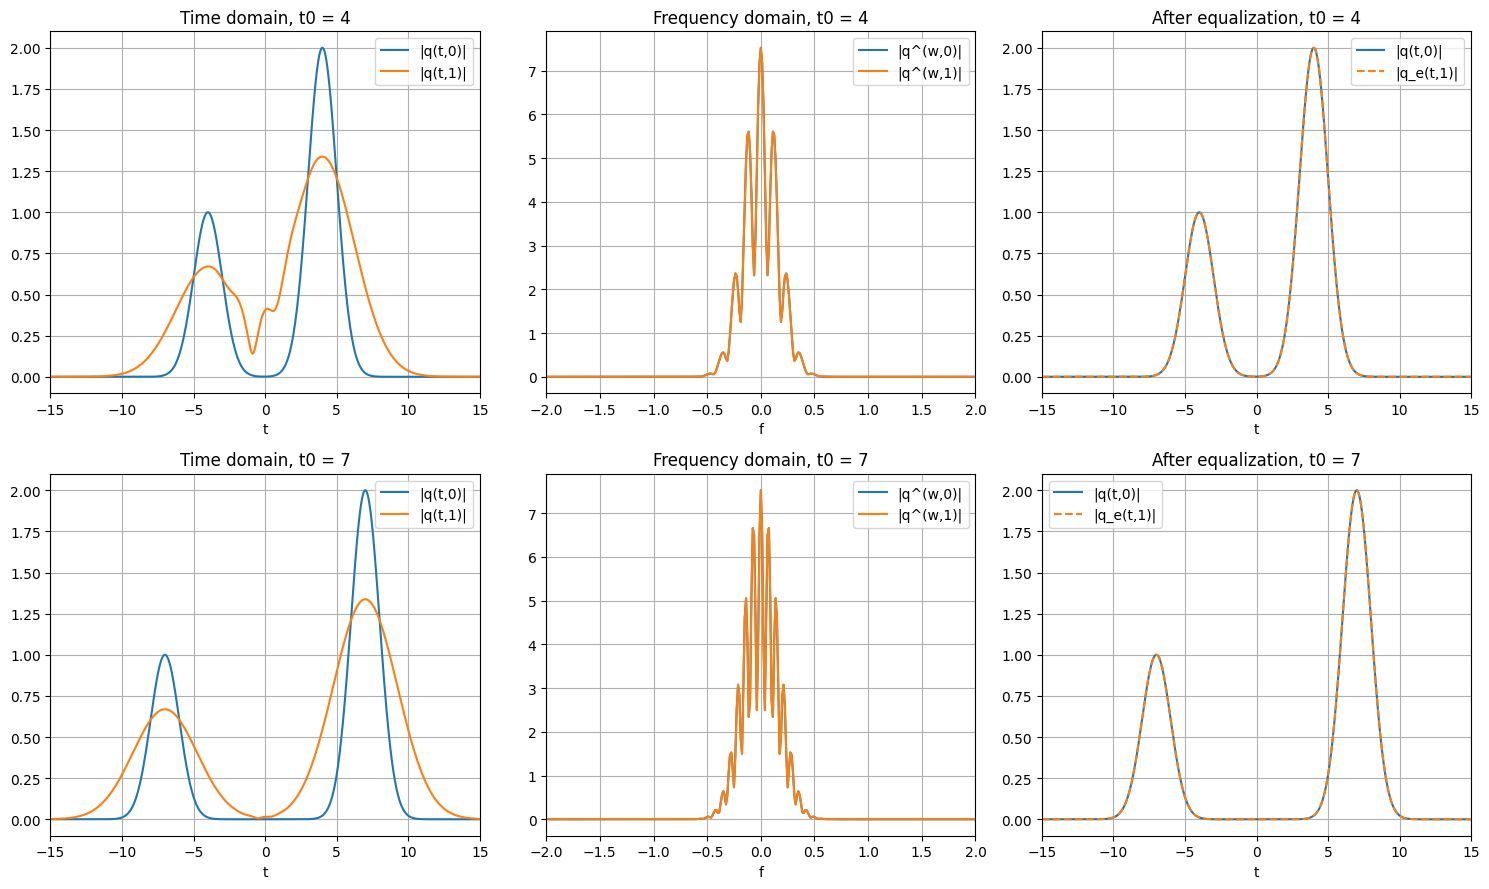

In [13]:
def two_pulse(t, t0, A1=1, A2=2, D=1):
    return (A1 * np.exp(-((t + t0)**2) / (2 * D**2)) + A2 * np.exp(-((t - t0)**2) / (2 * D**2)))

T  = 80
N  = 2**14
dt = T / N
t  = np.arange(-N//2, N//2) * dt
df = 1 / T
f  = np.arange(-N//2, N//2) * df

z = 1.0
B = 1.0

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for row, t0 in enumerate([4, 7]):
    q0t      = two_pulse(t, t0=t0, A1=1, A2=2, D=1)
    qzt, qzf = channel(t, q0t, z, sigma2=0.0, B=B)
    qzte, _  = equalize(t, qzt, z)
    q0f      = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(q0t))) * dt

    axes[row, 0].plot(t, np.abs(q0t), label='|q(t,0)|')
    axes[row, 0].plot(t, np.abs(qzt), label='|q(t,1)|')
    axes[row, 0].set_xlim([-15, 15])
    axes[row, 0].set_title(f"Time domain, t0 = {t0}")
    axes[row, 0].set_xlabel("t")
    axes[row, 0].grid(True)
    axes[row, 0].legend()

    axes[row, 1].plot(f, np.abs(q0f), label='|q^(w,0)|')
    axes[row, 1].plot(f, np.abs(qzf), label='|q^(w,1)|')
    axes[row, 1].set_xlim([-2, 2])
    axes[row, 1].set_title(f"Frequency domain, t0 = {t0}")
    axes[row, 1].set_xlabel("f")
    axes[row, 1].grid(True)
    axes[row, 1].legend()

    axes[row, 2].plot(t, np.abs(q0t), label='|q(t,0)|')
    axes[row, 2].plot(t, np.abs(qzte), '--', label='|q_e(t,1)|')
    axes[row, 2].set_xlim([-15, 15])
    axes[row, 2].set_title(f"After equalization, t0 = {t0}")
    axes[row, 2].set_xlabel("t")
    axes[row, 2].grid(True)
    axes[row, 2].legend()

plt.tight_layout()
plt.show()

---

#### 2.3.5 Performance evaluation
##### Question 22

In [14]:
def ser(s, stilde):
    s = np.asarray(s).reshape(-1)
    stilde = np.asarray(stilde).reshape(-1)
    return np.mean(stilde != s)

def ber(b, bhat):
    b = np.asarray(b).reshape(-1)
    bhat = np.asarray(bhat).reshape(-1)
    return np.mean(bhat != b)

In [15]:
# Fast datadset pipeline

@lru_cache(maxsize=32)
def _sinc_matrices(ns, N, T_round, Bn_round):
    dt   = T_round / N
    t    = np.arange(-N // 2, N // 2) * dt
    l1   = -(ns // 2)
    ells = np.arange(l1, l1 + ns)
    sm   = np.sinc(Bn_round * t[None, :] - ells[:, None]).astype(np.complex128)
    sm_H = Bn_round * dt * sm.conj()
    f    = np.fft.fftfreq(N, d=dt)
    w    = 2 * np.pi * f
    return sm, sm_H, t, dt, w

@lru_cache(maxsize=32)
def _rrc_matrices(ns, N, T_round, Bn_round, alpha_round):
    dt   = T_round / N
    t    = np.arange(-N // 2, N // 2) * dt
    l1   = -(ns // 2)
    ells = np.arange(l1, l1 + ns)
    sm   = np.array([rrc_pulse(t - ell / Bn_round, Bn_round, alpha_round) for ell in ells], dtype=np.complex128)
    sm_H = Bn_round * dt * sm.conj()
    f    = np.fft.fftfreq(N, d=dt)
    w    = 2 * np.pi * f
    return sm, sm_H, t, dt, w

def get_matrices(ns, Bn_norm=None, pulse='sinc', alpha=0.25):
    if Bn_norm is None:
        Bn_norm = Bn
    T_sym = 1.0 / Bn_norm
    T     = 1.5 * ns * T_sym
    N     = int(2 ** np.ceil(np.log2(T * 8 * Bn_norm)))
    if pulse == 'sinc':
        return _sinc_matrices(ns, N, round(T, 6), round(Bn_norm, 6))
    elif pulse == 'rrc':
        return _rrc_matrices(ns, N, round(T, 6), round(Bn_norm, 6),
                             round(alpha, 4))
    else:
        raise ValueError(f"Unknown pulse: {pulse!r}")



[SINC] running BER sweep ...
  SNR =  0 dB | BER = 2.8258e-01 | SER = 7.3484e-01
  SNR =  2 dB | BER = 2.3719e-01 | SER = 6.7406e-01
  SNR =  4 dB | BER = 1.8969e-01 | SER = 5.9234e-01
  SNR =  6 dB | BER = 1.4250e-01 | SER = 4.8609e-01
  SNR =  8 dB | BER = 9.8008e-02 | SER = 3.5453e-01
  SNR = 10 dB | BER = 5.8750e-02 | SER = 2.2281e-01
  SNR = 12 dB | BER = 2.8125e-02 | SER = 1.0969e-01
  SNR = 14 dB | BER = 1.0352e-02 | SER = 4.1406e-02
  SNR = 16 dB | BER = 1.6797e-03 | SER = 6.7187e-03
  SNR = 18 dB | BER = 7.8125e-05 | SER = 3.1250e-04
  SNR = 20 dB | BER = 0.0000e+00 | SER = 0.0000e+00

[RRC] running BER sweep ...
  SNR =  0 dB | BER = 2.8453e-01 | SER = 7.3406e-01
  SNR =  2 dB | BER = 2.2988e-01 | SER = 6.6422e-01
  SNR =  4 dB | BER = 1.8148e-01 | SER = 5.7141e-01
  SNR =  6 dB | BER = 1.3422e-01 | SER = 4.5750e-01
  SNR =  8 dB | BER = 9.6367e-02 | SER = 3.4906e-01
  SNR = 10 dB | BER = 5.2109e-02 | SER = 1.9672e-01
  SNR = 12 dB | BER = 2.4961e-02 | SER = 9.8281e-02
  SNR

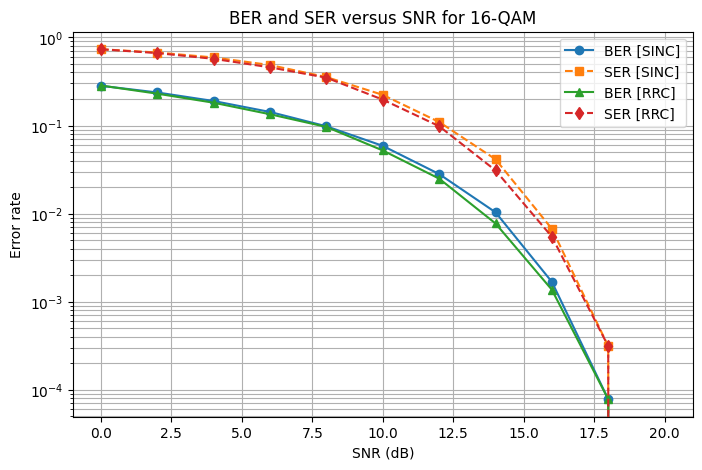

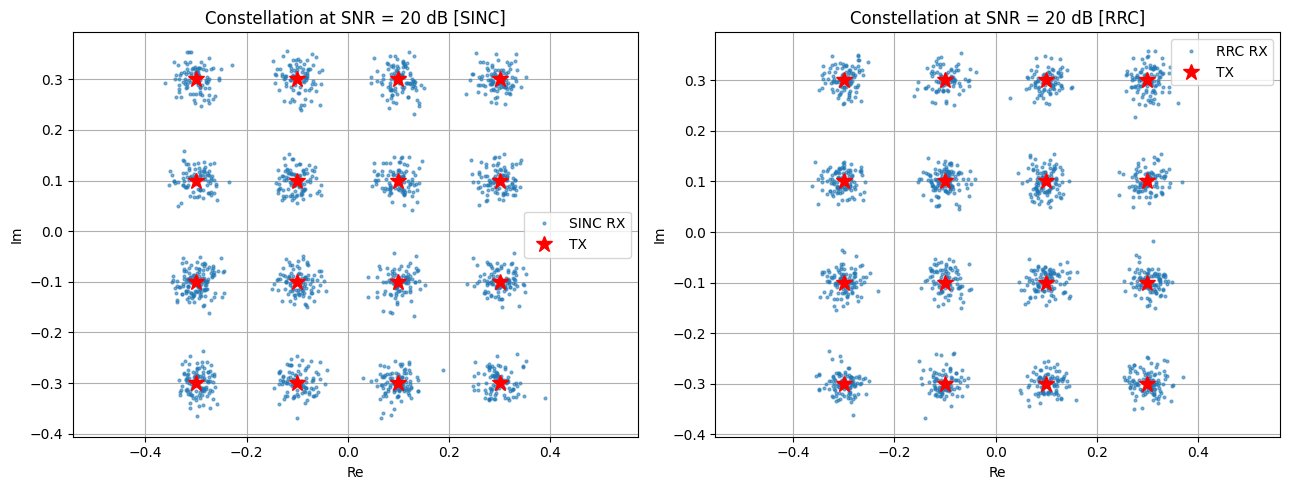

In [25]:
M = 16
B = 1
z = 1
ns = 32
Nr = 200
nb = ns * int(np.log2(M))
snr_db_vec = np.arange(0, 21, 2)
cnt0 = constellation(M, 1)
sigma2_test = 1e-3
alpha_rrc = 0.25

results = {}

for pulse in ['sinc', 'rrc']:
    ber_vec = []
    ser_vec = []

    print(f"\n[{pulse.upper()}] running BER sweep ...")

    # Precompute modulation / demodulation matrices once
    sm, sm_H, t_fast, dt_fast, w_fast = get_matrices(ns, Bn_norm=B, pulse=pulse, alpha=alpha_rrc)

    for snr_db_i in snr_db_vec:
        snr_lin = 10 ** (snr_db_i / 10)
        a = np.sqrt(snr_lin * sigma2_test * B * z)
        cnt_i = a * cnt0

        total_sym_errors = 0
        total_bit_errors = 0
        total_symbols = 0
        total_bits = 0

        for _ in range(Nr):
            # random bits and mapped symbols
            b_ = source(nb, 0.5)
            s_ = bit_to_symb(b_, cnt_i)

            # fast modulation
            q0_ = s_ @ sm

            # propagation and equalization
            qz_, _ = channel(t_fast, q0_, z, sigma2_test, B)
            qze_, _ = equalize(t_fast, qz_, z)

            # fast demodulation
            sh_ = sm_H @ qze_

            # detection and demapping
            st_ = detector(sh_, cnt_i)
            bh_ = symb_to_bit(st_, cnt_i)

            total_sym_errors += np.sum(st_ != s_)
            total_bit_errors += np.sum(bh_ != b_)
            total_symbols += len(s_)
            total_bits += len(b_)

        ser_i = total_sym_errors / total_symbols
        ber_i = total_bit_errors / total_bits

        ser_vec.append(ser_i)
        ber_vec.append(ber_i)

        print(f"  SNR = {snr_db_i:2d} dB | BER = {ber_i:.4e} | SER = {ser_i:.4e}")

    results[pulse] = {
        "ber": np.array(ber_vec),
        "ser": np.array(ser_vec)
    }

# BER / SER plot
plt.figure(figsize=(8, 5))
plt.semilogy(snr_db_vec, results['sinc']['ber'], 'o-',  label='BER [SINC]')
plt.semilogy(snr_db_vec, results['sinc']['ser'], 's--', label='SER [SINC]')
plt.semilogy(snr_db_vec, results['rrc']['ber'],  '^-',  label='BER [RRC]')
plt.semilogy(snr_db_vec, results['rrc']['ser'],  'd--', label='SER [RRC]')
plt.xlabel('SNR (dB)')
plt.ylabel('Error rate')
plt.title('BER and SER versus SNR for 16-QAM')
plt.grid(True, which='both')
plt.legend()
plt.show()

# Constellation plots at SNR = 20 dB
snr_plot_db = 20
snr_lin = 10 ** (snr_plot_db / 10)
a = np.sqrt(snr_lin * sigma2_test * B * z)
cnt_i = a * cnt0

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, pulse in zip(axes, ['sinc', 'rrc']):
    sm, sm_H, t_fast, dt_fast, w_fast = get_matrices(ns, Bn_norm=B, pulse=pulse, alpha=alpha_rrc)

    shat_all = []
    for _ in range(50):
        b_ = source(nb, 0.5)
        s_ = bit_to_symb(b_, cnt_i)
        q0_ = s_ @ sm
        qz_, _ = channel(t_fast, q0_, z, sigma2_test, B)
        qze_, _ = equalize(t_fast, qz_, z)
        sh_ = sm_H @ qze_
        shat_all.append(sh_)

    shat_all = np.concatenate(shat_all)

    ax.plot(shat_all.real, shat_all.imag, '.', alpha=0.55, ms=4, label=f'{pulse.upper()} RX')
    ax.plot(cnt_i.real, cnt_i.imag, '*r', ms=12, label='TX', zorder=5)

    ax.set_xlabel('Re')
    ax.set_ylabel('Im')
    ax.set_title(f'Constellation at SNR = {snr_plot_db} dB [{pulse.upper()}]')
    ax.grid(True)
    ax.axis('equal')
    ax.legend()

plt.tight_layout()
plt.show()

---

## 3 Generative neural network

### 3.2 Nonlinear transformation

##### Question 23

In [16]:
def noise_vec(n, sigma2):
    return np.sqrt(sigma2 / 2) * (np.random.randn(n) + 1j * np.random.randn(n))


---

##### Question 24

In [17]:
def sigma_activation(x, dz):
    return x * np.exp(-2j * dz * np.abs(x)**2)

def dft_matrix(n):
    k = np.arange(n)
    m = np.arange(n)
    return np.exp(-2j * np.pi * np.outer(k, m) / n) / np.sqrt(n)

In [18]:
def nnet_gen(x, nz=500, params=None):
    x = np.asarray(x, dtype=np.complex128).reshape(-1)

    n = len(x)

    # parameters
    z = params["z"]              # total propagation distance
    T = params["T"]              # total time window
    Bn = params["Bn"]            # normalized bandwidth
    sigma2 = params["sigma2"]    # normalized noise parameter

    # frequency vector
    dt = T / n
    f = np.fft.fftfreq(n, d=dt)
    w = 2 * np.pi * f

    # distance step
    dz = z / nz

    # linear step in frequency
    hhat = np.exp(1j * w**2 * dz)

    # DFT matrix
    D = dft_matrix(n)

    # fixed weight matrix W = D^H Gamma D
    Gamma = np.diag(hhat)
    W = D.conj().T @ Gamma @ D

    # per-layer noise power
    Pn = sigma2 * Bn * dz

    # loop over layers
    for _ in range(nz):
        # linear transformation
        x = W @ x

        # nonlinear transformation
        x = sigma_activation(x, dz)

        # noise addition
        x = x + noise_vec(n, Pn)

    y = x
    return y

---

## 4 Neural Network Equalizer


For the final implementation, we use a **symbols-to-symbol** equalizer. In our implementation, the input of the predictive NN is the block of **soft symbols** obtained after the nonlinear channel, the linear equalizer, and the demodulator, and the target is the transmitted symbol block.

Thus, each training example is a pair $(\hat s^{(i)}, s^{(i)}),$ where $\hat s^{(i)}$ is the noisy/distorted soft symbol block and $s^{(i)}$ is the transmitted symbol block.

We choose $n_{\text{examples}}=12500, n_s=32,$ which gives $12500 \times 32 = 400000$ symbols in total, which lies in the required range.

To match the grading operating point, the dataset is generated at 16-QAM, bandwidth 10 GHz, distance 1000 km, and SNR 35 dB.

In [19]:
# ── SSFM (nonlinear channel) ─────────────────────────────────────────────────
def ssfm(q0, nz, w):
    x   = q0.copy()
    N   = len(x)
    dz  = 1.0 / nz
    hhat = np.exp(1j * w**2 * dz)
    Pn  = sigma2 * Bn * dz
    sq  = np.sqrt(Pn / 2)
    for _ in range(nz):
        x  = np.fft.ifft(hhat * np.fft.fft(x))
        x  = x * np.exp(-2j * dz * np.abs(x)**2)
        x += sq * (np.random.randn(N) + 1j * np.random.randn(N))
    return x

def equalize_fast(qzt, w):
    return np.fft.ifft(np.exp(-1j * w**2) * np.fft.fft(qzt))

# ── Phase correction ─────────────────────────────────────────────────────────
def estimate_mean_phase_rotation(X_raw, Y_raw, n_samples=50000):
    x    = X_raw.reshape(-1)[:n_samples]
    y    = Y_raw.reshape(-1)[:n_samples]
    mask = np.abs(y) > 1e-6
    ratio = x[mask] / y[mask]
    return np.angle(np.mean(ratio / np.abs(ratio)))

def phase_correct(X, angle):
    return X * np.exp(-1j * angle)

# ── Normalization ─────────────────────────────────────────────────────────────
def fit_norm(X):
    return (X.real.mean(), X.imag.mean(),
            X.real.std() + 1e-8, X.imag.std() + 1e-8)

def norm(X, mu_r, mu_i, std_r, std_i):
    return (X.real - mu_r) / std_r + 1j * ((X.imag - mu_i) / std_i)

def denorm(X, mu_r, mu_i, std_r, std_i):
    return X.real * std_r + mu_r + 1j * (X.imag * std_i + mu_i)

# ── Tensor helpers ────────────────────────────────────────────────────────────
def c2ch(Xc):   return np.stack([Xc.real, Xc.imag], 1).astype(np.float32)
def c2flat(Yc): return np.concatenate([Yc.real, Yc.imag], 1).astype(np.float32)
def flat2c(a):  h = a.shape[1] // 2; return a[:, :h] + 1j * a[:, h:]

def split_data(X, Y, tr=0.8, va=0.1, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))
    nt  = int(tr * len(X)); nv = int(va * len(X))
    return (X[idx[:nt]], Y[idx[:nt]],
            X[idx[nt:nt+nv]], Y[idx[nt:nt+nv]],
            X[idx[nt+nv:]], Y[idx[nt+nv:]])

def make_loaders(Xtr, Ytr, Xva, Yva, Xte, Yte, bs=256):
    def ds(X, Y): return TensorDataset(torch.from_numpy(X), torch.from_numpy(Y))
    return (DataLoader(ds(Xtr, Ytr), bs, shuffle=True),
            DataLoader(ds(Xva, Yva), bs, shuffle=False),
            DataLoader(ds(Xte, Yte), bs, shuffle=False))

# ── Dataset generation ────────────────────────────────────────────────────────
def generate_dataset(n_examples=12500, ns_block=32, snr_db=35.0,
                     nz=100, seed=0, pulse='sinc', alpha=0.25):
    np.random.seed(seed)
    M        = 16
    cnt0     = constellation(M, 1.0)
    snr_lin  = 10 ** (snr_db / 10.0)
    a        = np.sqrt(snr_lin * sigma2 * Bn)
    cnt_sc   = a * cnt0

    sm, sm_H, t, dt, w = get_matrices(ns_block, pulse=pulse, alpha=alpha)
    N  = len(t)
    nb = ns_block * int(np.log2(M))
    print(f"  [{pulse.upper()}] Mesh: T={N*dt:.2f}, N={N}, nz={nz}")
    print(f"  SNR={snr_db} dB  a={a:.4f}  E[|s|²]={a**2:.4e}")

    X = np.zeros((n_examples, ns_block), dtype=np.complex128)
    Y = np.zeros((n_examples, ns_block), dtype=np.complex128)

    for i in range(n_examples):
        if i % 3000 == 0:
            print(f"  [{i}/{n_examples}]")
        bk   = source(nb, 0.5)
        s    = bit_to_symb(bk, cnt_sc)
        q0t  = s @ sm
        qzt  = ssfm(q0t, nz, w)
        qze  = equalize_fast(qzt, w)
        shat = sm_H @ qze
        X[i] = shat
        Y[i] = s

    meta = dict(cnt0=cnt0, cnt=cnt_sc, snr_db=snr_db,
                ns_block=ns_block, a=a, pulse=pulse, alpha=alpha,
                total_symbols=n_examples * ns_block)
    print(f"  Done: {meta['total_symbols']} symbols")
    return X, Y, meta

In [20]:
# ── Architecture 1: Dilated Residual CNN ─────────────────────────────────────
class DilatedResBlock(nn.Module):
    def __init__(self, channels, kernel_size=5, dilation=1):
        super().__init__()
        pad = dilation * (kernel_size - 1) // 2
        C   = channels
        self.conv1r = nn.Conv1d(C, C, kernel_size, padding=pad, dilation=dilation)
        self.conv1i = nn.Conv1d(C, C, kernel_size, padding=pad, dilation=dilation)
        self.conv2r = nn.Conv1d(C, C, kernel_size, padding=pad, dilation=dilation)
        self.conv2i = nn.Conv1d(C, C, kernel_size, padding=pad, dilation=dilation)
        self.bn1r = nn.BatchNorm1d(C); self.bn1i = nn.BatchNorm1d(C)
        self.bn2r = nn.BatchNorm1d(C); self.bn2i = nn.BatchNorm1d(C)

    def _cc(self, xr, xi, lr, li, br, bi):
        yr = br(lr(xr) - li(xi))
        yi = bi(lr(xi) + li(xr))
        return yr, yi

    def forward(self, x):
        C  = x.size(1) // 2
        xr, xi = x[:, :C], x[:, C:]
        yr, yi = self._cc(xr, xi, self.conv1r, self.conv1i, self.bn1r, self.bn1i)
        yr = F.relu(yr); yi = F.relu(yi)
        yr, yi = self._cc(yr, yi, self.conv2r, self.conv2i, self.bn2r, self.bn2i)
        yr = F.relu(yr + xr); yi = F.relu(yi + xi)
        return torch.cat([yr, yi], dim=1)

class DilatedCNNEqualizer(nn.Module):
    def __init__(self, ns=32, channels=8, kernel_size=5):
        super().__init__()
        C = channels
        self.in_r  = nn.Conv1d(1, C, 1); self.in_i  = nn.Conv1d(1, C, 1)
        self.blocks = nn.ModuleList([
            DilatedResBlock(C, kernel_size, dilation=2**i) for i in range(4)])
        self.out_r = nn.Conv1d(C, 1, 1); self.out_i = nn.Conv1d(C, 1, 1)

    def forward(self, x):
        xr, xi = x[:, 0:1], x[:, 1:2]
        yr = F.relu(self.in_r(xr) - self.in_i(xi))
        yi = F.relu(self.in_r(xi) + self.in_i(xr))
        h  = torch.cat([yr, yi], dim=1)
        for blk in self.blocks:
            h = blk(h)
        C  = h.size(1) // 2
        hr, hi = h[:, :C], h[:, C:]
        yr = self.out_r(hr) - self.out_i(hi)
        yi = self.out_r(hi) + self.out_i(hr)
        return torch.cat([yr, yi], dim=1).reshape(x.size(0), -1)

# ── Architecture 2: BiLSTM-FC ─────────────────────────────────────────────────
class BiLSTMFCEqualizer(nn.Module):
    def __init__(self, hidden=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(2, hidden, num_layers,
                            batch_first=True, bidirectional=True)
        self.fc1 = nn.Linear(2 * hidden, 2 * hidden)
        self.fc2 = nn.Linear(2 * hidden, 2)

    def forward(self, x):
        h, _ = self.lstm(x.transpose(1, 2))
        h    = torch.tanh(self.fc1(h))
        y    = self.fc2(h)
        return y.reshape(x.size(0), -1)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

# ── Training ──────────────────────────────────────────────────────────────────
def train_model(model, tr_ld, va_ld,
                lr=1e-3, epochs=200, patience=25, device="cpu"):
    model.to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, patience=4, factor=0.5, min_lr=1e-6)
    crit  = nn.MSELoss()
    best_val, best_st, bad = float("inf"), None, 0
    hist  = {"train": [], "val": []}

    for ep in range(1, epochs + 1):
        model.train(); tl, nt = 0., 0
        for xb, yb in tr_ld:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tl += loss.item() * xb.size(0); nt += xb.size(0)
        tl /= nt

        model.eval(); vl, nv = 0., 0
        with torch.no_grad():
            for xb, yb in va_ld:
                xb, yb = xb.to(device), yb.to(device)
                vl += crit(model(xb), yb).item() * xb.size(0); nv += xb.size(0)
        vl /= nv
        sched.step(vl)
        hist["train"].append(tl); hist["val"].append(vl)

        if ep % 20 == 0:
            print(f"  ep {ep:3d} | train {tl:.4e} | val {vl:.4e} "
                  f"| lr {opt.param_groups[0]['lr']:.1e}")
        if vl < best_val:
            best_val = vl
            best_st  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"  Early stopping at epoch {ep}")
                break

    model.load_state_dict(best_st)
    return model, hist

# ── Mutual information ────────────────────────────────────────────────────────
def mutual_information(true_sym, det_sym, cnt):
    M   = len(cnt)
    c2i = {c: i for i, c in enumerate(cnt)}
    C   = np.zeros((M, M), dtype=np.float64)
    for a, b in zip(true_sym, det_sym):
        C[c2i[a], c2i[b]] += 1
    row_sums = C.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    P  = C / row_sums
    p  = P[0]; nz = p > 0
    H  = -np.sum(p[nz] * np.log2(p[nz]))
    MI = np.log2(M) - H
    diag   = np.diag(P)
    p_d    = np.zeros(M)
    p_d[0] = diag.mean()
    p_d[1:] = (1 - diag.mean()) / max(M - 1, 1)
    nz2 = p_d > 0
    H_d  = -np.sum(p_d[nz2] * np.log2(p_d[nz2]))
    MI_d = np.log2(M) - H_d
    return MI, C, dict(MI_diag=MI_d, mean_SER=1 - diag.mean(), P=P)

# ── Evaluate ──────────────────────────────────────────────────────────────────
def evaluate_model(model, te_ld, cnt, norm_stats, device="cpu"):
    mu_r, mu_i, std_r, std_i = norm_stats
    model.eval(); model.to(device)
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in te_ld:
            preds.append(model(xb.to(device)).cpu().numpy())
            trues.append(yb.numpy())
    pred_n = flat2c(np.concatenate(preds))
    true_n = flat2c(np.concatenate(trues))
    pred   = denorm(pred_n, mu_r, mu_i, std_r, std_i).reshape(-1)
    true   = denorm(true_n, mu_r, mu_i, std_r, std_i).reshape(-1)
    true_h = detector(true, cnt)
    det_s  = detector(pred, cnt)
    bhat   = symb_to_bit(det_s, cnt)
    btrue  = symb_to_bit(true_h, cnt)
    ber_v  = np.mean(bhat != btrue)
    ser_v  = np.mean(det_s != true_h)
    MI, C, extras = mutual_information(true_h, det_s, cnt)
    print(f"  BER={ber_v:.6e}  SER={ser_v:.6e}  MI={MI:.8f}")
    return dict(pred=pred, true=true_h, det=det_s,
                ber=ber_v, ser=ser_v, mi=MI,
                mi_diag=extras['MI_diag'], C=C,
                n_params=count_params(model))

In [27]:
def run_nn_experiment(pulse='sinc', alpha=0.25, device='cpu', n_examples=12500, epochs=200):
    print(f"\n{'='*70}")
    print(f"NN EXPERIMENT  [{pulse.upper()}]  alpha={alpha if pulse=='rrc' else 'N/A'}")
    print('='*70)

    # ── 1. Dataset ────────────────────────────────────────────────────────────
    X_raw, Y_raw, meta = generate_dataset(
        n_examples=n_examples, ns_block=32, snr_db=35.0,
        nz=100, seed=0, pulse=pulse, alpha=alpha)
    cnt = meta["cnt"]

    # ── 2. Phase correction ───────────────────────────────────────────────────
    n_tr = int(0.8 * len(X_raw))
    mean_angle = estimate_mean_phase_rotation(X_raw[:n_tr], Y_raw[:n_tr])
    print(f"  Mean phase rotation: {np.degrees(mean_angle):.2f} deg")
    X_pc = phase_correct(X_raw, mean_angle)

    # ── 3. Normalise ──────────────────────────────────────────────────────────
    norm_stats = fit_norm(X_pc[:n_tr])
    X_norm = norm(X_pc, *norm_stats)
    Y_norm = norm(Y_raw, *norm_stats)

    # ── 4. Tensors & loaders ──────────────────────────────────────────────────
    X_nn = c2ch(X_norm); Y_nn = c2flat(Y_norm)
    Xtr, Ytr, Xva, Yva, Xte, Yte = split_data(X_nn, Y_nn, seed=0)
    tr_ld, va_ld, te_ld = make_loaders(Xtr, Ytr, Xva, Yva, Xte, Yte, bs=256)
    print(f"  Train {Xtr.shape}  Val {Xva.shape}  Test {Xte.shape}")

    # ── 5. Linear baseline ────────────────────────────────────────────────────
    bs = X_pc.reshape(-1); bt = Y_raw.reshape(-1)
    bh = detector(bt, cnt); bd = detector(bs, cnt)
    bber = float(np.mean(symb_to_bit(bd, cnt) != symb_to_bit(bh, cnt)))
    bmi, _, bex = mutual_information(bh, bd, cnt)
    print(f"  Baseline (linear) BER={bber:.4e}  MI={bmi:.4f}")

    # ── 6. Dilated CNN ────────────────────────────────────────────────────────
    print("\n  --- Dilated CNN ---")
    dcnn = DilatedCNNEqualizer(ns=32, channels=10, kernel_size=5)
    print(f"  #params = {count_params(dcnn)}")
    dcnn, hist_d = train_model(dcnn, tr_ld, va_ld,
                               lr=5e-2, epochs=epochs, patience=20, device=device)
    res_d = evaluate_model(dcnn, te_ld, cnt, norm_stats, device=device)

    # ── 7. BiLSTM-FC ──────────────────────────────────────────────────────────
    print("\n  --- BiLSTM-FC ---")
    bilstm = BiLSTMFCEqualizer(hidden=64, num_layers=1)
    print(f"  #params = {count_params(bilstm)}")
    bilstm, hist_b = train_model(bilstm, tr_ld, va_ld,
                                 lr=1e-1, epochs=epochs, patience=20, device=device)
    res_b = evaluate_model(bilstm, te_ld, cnt, norm_stats, device=device)

    # ── 8. Summary table ──────────────────────────────────────────────────────
    print(f"\n  {'Model':<20}{'BER':>12}{'SER':>10}{'MI':>8}{'#params':>9}")
    print("  " + "-"*60)
    print(f"  {'Linear (no NN)':<20}{bber:>12.4e}{'—':>10}{bmi:>8.4f}{'0':>9}")
    for name, res in [('Dilated CNN', res_d), ('BiLSTM-FC', res_b)]:
        print(f"  {name:<20}{res['ber']:>12.4e}{res['ser']:>10.4e}"
              f"{res['mi']:>8.4f}{res['n_params']:>9}")

    # ── 9. Plots ──────────────────────────────────────────────────────────────
    tag = pulse.upper()

    # Training curves
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.semilogy(hist_d["train"], label="Dilated CNN train")
    ax.semilogy(hist_d["val"],   label="Dilated CNN val")
    ax.semilogy(hist_b["train"], label="BiLSTM-FC train")
    ax.semilogy(hist_b["val"],   label="BiLSTM-FC val")
    ax.set_xlabel("epoch"); ax.set_ylabel("MSE (log)")
    ax.set_title(f"Training curves [{tag}]")
    ax.grid(True); ax.legend(); plt.tight_layout()
    plt.show()

    # Constellation plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    panels = [
        ("Before NN (phase corrected)", X_pc.reshape(-1), None),
        (f"Dilated CNN BER={res_d['ber']:.2e}", res_d['pred'], res_d),
        (f"BiLSTM-FC BER={res_b['ber']:.2e}", res_b['pred'], res_b),
    ]
    for ax, (title, pts, _) in zip(axes, panels):
        ax.plot(cnt.real, cnt.imag, '*r', ms=10, zorder=3, label='TX')
        ax.plot(pts.real, pts.imag, '.', alpha=0.15, ms=1, label=title)
        ax.set_xlabel("Re"); ax.set_ylabel("Im"); ax.axis("equal")
        ax.set_title(f"[{tag}] {title}"); ax.grid(True)
    plt.tight_layout()
    plt.show()

    return dict(pulse=pulse, baseline_ber=bber, baseline_mi=bmi,
                dcnn=res_d, bilstm=res_b,
                hist_d=hist_d, hist_b=hist_b, cnt=cnt, X_pc=X_pc)


In [28]:
# FINAL COMPARISON

def plot_final_comparison(res_sinc, res_rrc):
    print("\n  Building final comparison figure ...")

    # Summary table
    print("\n" + "="*80)
    print(f"{'Model':<26}{'BER':>14}{'SER':>10}{'MI (bits/sym)':>15}{'#params':>10}")
    print("-"*80)
    for label, ber_v, ser_v, mi_v, np_ in [
        ("SINC – Linear",        res_sinc['baseline_ber'], None, res_sinc['baseline_mi'], 0),
        ("SINC – Dilated CNN",   res_sinc['dcnn']['ber'],  res_sinc['dcnn']['ser'],
                                  res_sinc['dcnn']['mi'],  res_sinc['dcnn']['n_params']),
        ("SINC – BiLSTM-FC",     res_sinc['bilstm']['ber'], res_sinc['bilstm']['ser'],
                                  res_sinc['bilstm']['mi'],  res_sinc['bilstm']['n_params']),
        ("RRC  – Linear",        res_rrc['baseline_ber'], None, res_rrc['baseline_mi'], 0),
        ("RRC  – Dilated CNN",   res_rrc['dcnn']['ber'],  res_rrc['dcnn']['ser'],
                                  res_rrc['dcnn']['mi'],  res_rrc['dcnn']['n_params']),
        ("RRC  – BiLSTM-FC",     res_rrc['bilstm']['ber'], res_rrc['bilstm']['ser'],
                                  res_rrc['bilstm']['mi'],  res_rrc['bilstm']['n_params']),
    ]:
        ser_s = f"{ser_v:.4e}" if ser_v is not None else "   —"
        print(f"{label:<26}{ber_v:>14.4e}{ser_s:>10}{mi_v:>15.4f}{np_:>10}")
    print("="*80)

In [29]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda



NN EXPERIMENT  [SINC]  alpha=N/A
  [SINC] Mesh: T=46.12, N=512, nz=100
  SNR=35.0 dB  a=0.3444  E[|s|²]=1.1859e-01
  [0/12500]
  [3000/12500]
  [6000/12500]
  [9000/12500]
  [12000/12500]
  Done: 400000 symbols
  Mean phase rotation: -22.10 deg
  Train (10000, 2, 32)  Val (1250, 2, 32)  Test (1250, 2, 32)
  Baseline (linear) BER=4.5531e-03  MI=3.7632

  --- Dilated CNN ---
  #params = 8542
  ep  20 | train 3.9976e-03 | val 4.0525e-03 | lr 5.0e-02
  ep  40 | train 1.5197e-03 | val 2.5054e-03 | lr 1.3e-02
  ep  60 | train 9.3836e-04 | val 9.3419e-04 | lr 1.6e-03
  ep  80 | train 7.9190e-04 | val 8.5533e-04 | lr 3.9e-04
  ep 100 | train 7.5326e-04 | val 7.6179e-04 | lr 2.0e-04
  ep 120 | train 7.3084e-04 | val 7.5504e-04 | lr 2.0e-04
  ep 140 | train 6.9777e-04 | val 7.1625e-04 | lr 2.0e-04
  ep 160 | train 6.7220e-04 | val 6.8188e-04 | lr 2.0e-04
  ep 180 | train 6.2701e-04 | val 6.4983e-04 | lr 4.9e-05
  ep 200 | train 6.1162e-04 | val 6.4434e-04 | lr 4.9e-05
  BER=1.875000e-05  SER=7.

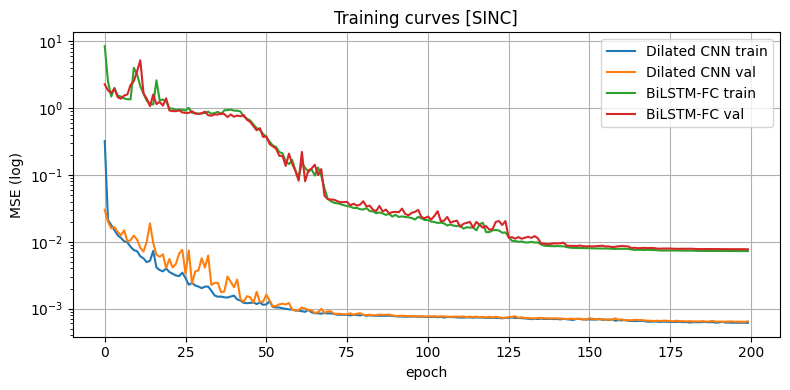

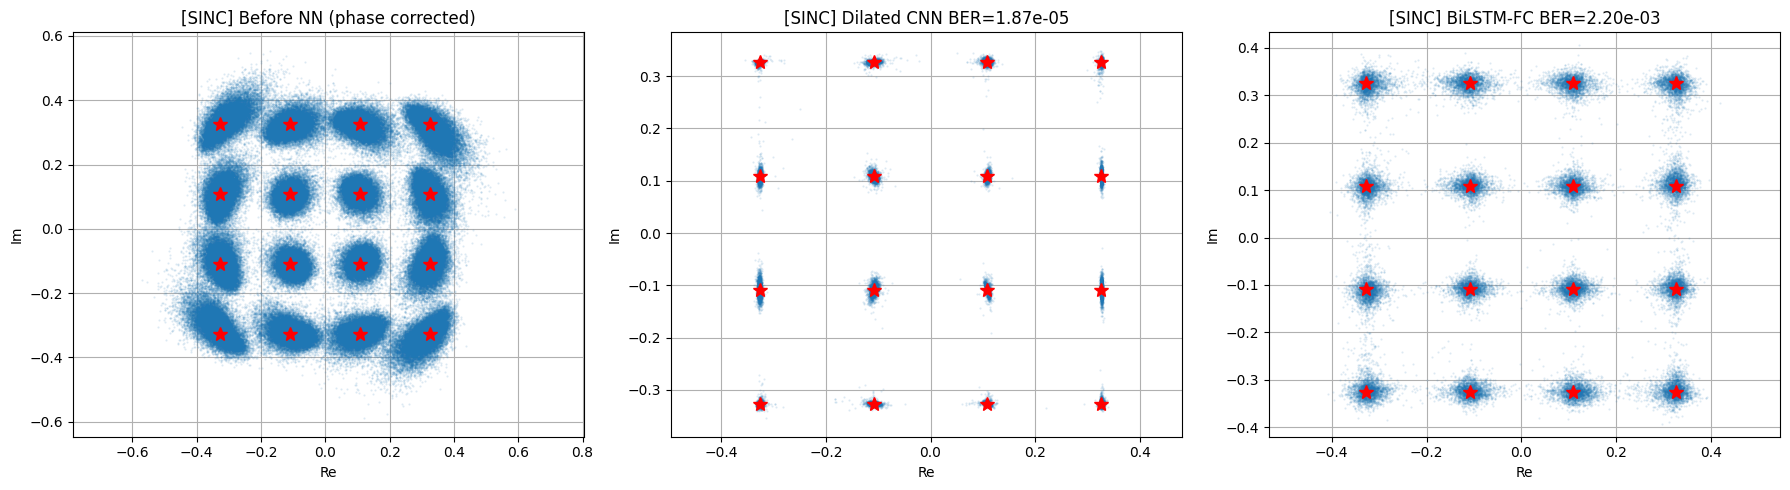

In [30]:
# NN equalizer – SINC
res_sinc = run_nn_experiment(pulse='sinc', device=device,
                              n_examples=12500, epochs=200)



NN EXPERIMENT  [RRC]  alpha=0.25
  [RRC] Mesh: T=46.12, N=512, nz=100
  SNR=35.0 dB  a=0.3444  E[|s|²]=1.1859e-01
  [0/12500]
  [3000/12500]
  [6000/12500]
  [9000/12500]
  [12000/12500]
  Done: 400000 symbols
  Mean phase rotation: -23.27 deg
  Train (10000, 2, 32)  Val (1250, 2, 32)  Test (1250, 2, 32)
  Baseline (linear) BER=4.3575e-03  MI=3.7988

  --- Dilated CNN ---
  #params = 8542
  ep  20 | train 3.6674e-03 | val 3.5150e-03 | lr 5.0e-02
  ep  40 | train 1.5624e-03 | val 1.9282e-03 | lr 2.5e-02
  ep  60 | train 9.0832e-04 | val 2.3972e-03 | lr 1.3e-02
  ep  80 | train 2.5882e-04 | val 4.7497e-04 | lr 3.1e-03
  ep 100 | train 8.3599e-05 | val 1.0089e-04 | lr 1.6e-03
  ep 120 | train 5.6321e-05 | val 4.3697e-05 | lr 7.8e-04
  ep 140 | train 3.6199e-05 | val 2.7343e-05 | lr 2.0e-04
  ep 160 | train 2.7542e-05 | val 2.5191e-05 | lr 4.9e-05
  ep 180 | train 2.4782e-05 | val 2.4725e-05 | lr 6.1e-06
  Early stopping at epoch 183
  BER=6.250000e-06  SER=2.500000e-05  MI=4.00000000

  

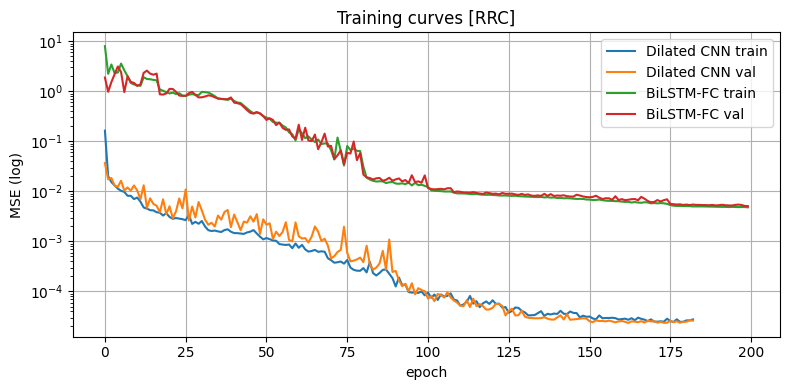

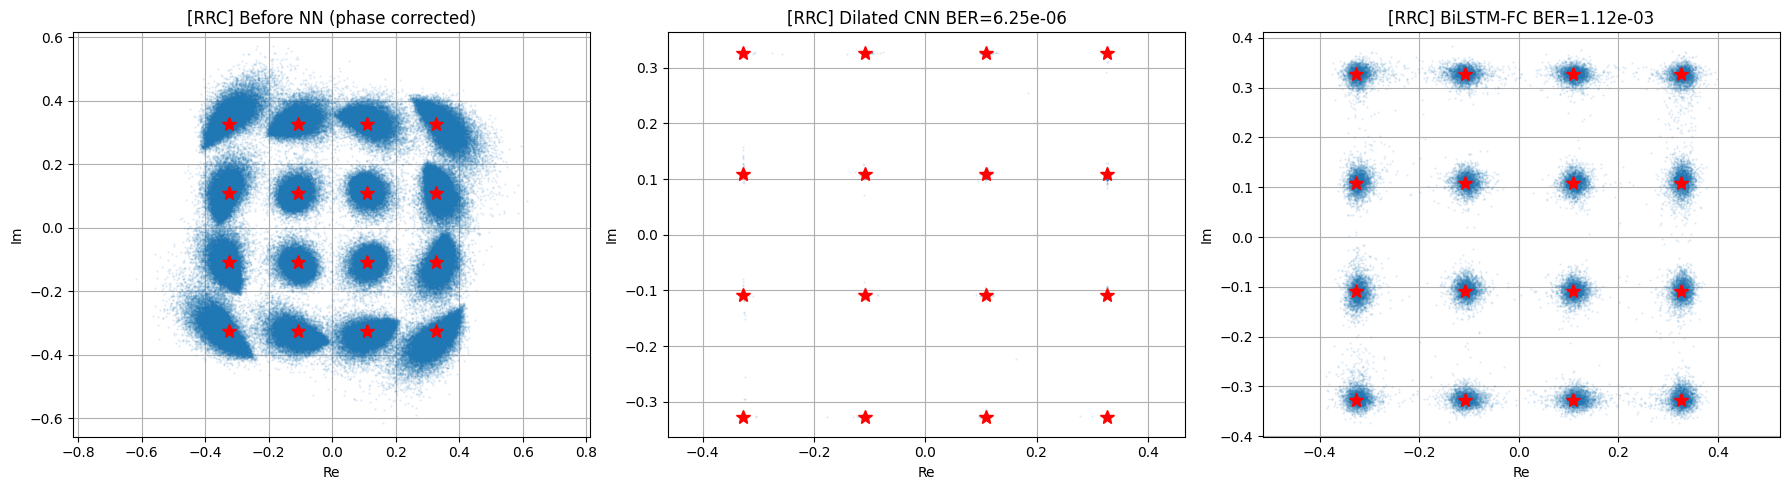

In [31]:
# NN equalizer – RRC (alpha = 0.25)
res_rrc  = run_nn_experiment(pulse='rrc', alpha=0.25, device=device,
                              n_examples=12500, epochs=200)

In [32]:
# Final comparison
plot_final_comparison(res_sinc, res_rrc)


  Building final comparison figure ...

Model                                BER       SER  MI (bits/sym)   #params
--------------------------------------------------------------------------------
SINC – Linear                 4.5531e-03         —         3.7632         0
SINC – Dilated CNN            1.8750e-057.5000e-05         4.0000      8542
SINC – BiLSTM-FC              2.2000e-038.5750e-03         3.9207     51586
RRC  – Linear                 4.3575e-03         —         3.7988         0
RRC  – Dilated CNN            6.2500e-062.5000e-05         4.0000      8542
RRC  – BiLSTM-FC              1.1187e-034.4500e-03         3.9761     51586
